# Интерпретация

In [6]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error
import lime
import lime.lime_tabular
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [7]:
data_path = r'hw_interpretation\data.csv'
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()

Размер датасета: (29905, 83)

Первые строки:


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


In [8]:
print(data['location_depth'].value_counts())
print()
print(data['location_depth.1'].value_counts())
print()
print(data['location_depth.2'].value_counts())

location_depth
13.0    29572
Name: count, dtype: int64

location_depth.1
13.0    29572
Name: count, dtype: int64

location_depth.2
13.0    29572
Name: count, dtype: int64


In [9]:
non_numeric_cols = data.select_dtypes(exclude=['number', 'bool']).columns.tolist()

print("Нечисловые столбцы:")
print(non_numeric_cols)

Нечисловые столбцы:
['region_name_cat', 'agreement_date', 'rooms_4']


In [10]:
print(data['region_name_cat'].value_counts())
print()
print(data['agreement_date'].value_counts())
print()
print(data['rooms_4'].value_counts())

region_name_cat
Город       23158
Пригород     6745
Область         2
Name: count, dtype: int64

agreement_date
2012-12-30    475
2013-03-28    275
2013-05-18    268
2013-03-17    235
2012-12-07    233
             ... 
2013-01-07      2
2012-01-01      1
2012-01-09      1
2013-01-05      1
2012-01-04      1
Name: count, Length: 529, dtype: int64

rooms_4
1         14180
2         10281
3          4427
>=4         643
студия      374
Name: count, dtype: int64


In [11]:
data = data.drop(columns=['location_depth.1', 'location_depth.2'], errors='ignore')

data['agreement_date'] = pd.to_datetime(data['agreement_date'])
data['year'] = data['agreement_date'].dt.year
data['month'] = data['agreement_date'].dt.month
data = data.drop('agreement_date', axis=1)

data['rooms_4'] = data['rooms_4'].replace({'студия': 0, '>=4': 4}).astype(float)

data = pd.get_dummies(data, columns=['region_name_cat'], prefix='region', drop_first=True)

data = data.replace(-999, np.nan)
data = data.fillna(data.median(numeric_only=True))

X = data.drop('price_target', axis=1)
y = data['price_target']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)

Train: (23924, 82)


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

In [13]:
# 1. Две версии данных
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 2. Обучаем 6 моделей
models = {}

# LinearRegression
models['LR_raw']    = LinearRegression().fit(X_train_raw, y_train)
models['LR_scaled'] = LinearRegression().fit(X_train_scaled, y_train)

# Lasso (alpha=1.0 по умолчанию)
models['Lasso_raw']    = Lasso(alpha=1.0, random_state=42, max_iter=10000).fit(X_train_raw, y_train)
models['Lasso_scaled'] = Lasso(alpha=1.0, random_state=42, max_iter=10000).fit(X_train_scaled, y_train)

# GradientBoostingRegressor(max_depth=5)
models['GB_raw']    = GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=100).fit(X_train_raw, y_train)
models['GB_scaled'] = GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=100).fit(X_train_scaled, y_train)

# 3. Подсчёт метрик
results = []
for name, model in models.items():
    if 'raw' in name:
        X_test_use = X_test_raw
    else:
        X_test_use = X_test_scaled
    
    pred = model.predict(X_test_use)
    
    mse  = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, pred) * 100
    
    results.append({
        'Модель': name,
        'MSE':  round(mse, 2),
        'RMSE': round(rmse, 2),
        'MAPE': round(mape, 3)
    })


df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))

      Модель         MSE    RMSE   MAPE
      LR_raw 23021507.39 4798.07 11.553
   LR_scaled 23021507.39 4798.07 11.553
   Lasso_raw 23222509.94 4818.97 11.687
Lasso_scaled 23007132.23 4796.58 11.530
      GB_raw  3524525.72 1877.37  4.030
   GB_scaled  3524244.70 1877.30  4.030


#### Какая метрика больше подходит для этой задачи?

- **MAPE (Mean Absolute Percentage Error)** — наиболее подходящая метрика для интерпретации в контексте недвижимости.  
  Ошибка в 4% для бустинга означает, что в среднем предсказанная цена отклоняется на 4% от реальной — это понятный и полезный показатель для риелторов, инвесторов и застройщиков.

- **RMSE** — полезен как абсолютная ошибка.  
  Позволяет понять, на сколько рублей в среднем ошибается модель.

- **MSE** — самая плохая для интерпретации (очень большие числа, квадратичный штраф на крупные ошибки).  
  Можно использовать только для оптимизации, но не для финальных выводов.

#### Чувствительность моделей к масштабированию признаков

| Тип модели              | Чувствительность к масштабу | Разница в MAPE | Причина чувствительности / инвариантности |
|-------------------------|-----------------------------|----------------|--------------------------------------------|
| LinearRegression        | Низкая (предсказания одинаковые) | 0%        | Предсказания инвариантны, но **коэффициенты** сильно меняются |
| Lasso (L1-регуляризация)| Средняя–высокая             | –0.157%        | Штраф L1 зависит от абсолютных значений коэффициентов, значит масштаб критичен |
| GradientBoosting        | Очень низкая (почти инвариантна) | ~0.000%   | Деревья решений и сплиты не зависят от масштаба признаков |

#### Почему чувствительность к масштабу важна именно для анализа признаков?

- В линейных моделях (особенно Lasso) без масштабирования:
  - признаки с большим диапазоном значений будут иметь искусственно завышенные коэффициенты;
  - признаки с маленьким диапазоном будут недооценены;

- В нелинейных моделях (бустинг, случайный лес и т.д.) масштаб почти не влияет, поэтому permutation importance, SHAP, PDP, ALE и встроенная feature importance работают корректно даже на необработанных данных.

## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

In [14]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.inspection import permutation_importance
import pandas as pd

scalers = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler()
}

scaled = {}
for name, sc in scalers.items():
    X_tr = sc.fit_transform(X_train)
    X_te = sc.transform(X_test)
    scaled[name] = {
        'train': pd.DataFrame(X_tr, columns=X_train.columns),
        'test':  pd.DataFrame(X_te, columns=X_test.columns)
    }

models = {}
for name in ['Standard', 'MinMax']:
    X_tr = scaled[name]['train']
    models[f'LR_{name}']    = LinearRegression().fit(X_tr, y_train)
    models[f'Lasso_{name}'] = Lasso(alpha=1, max_iter=10000, random_state=42).fit(X_tr, y_train)
    models[f'GB_{name}']    = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_tr, y_train)

importance = {}
for name in ['Standard', 'MinMax']:
    X_te = scaled[name]['test']
    for mdl in ['LR', 'Lasso', 'GB']:
        key = f'{mdl}_{name}'
        imp = permutation_importance(
            models[key], X_te, y_test,
            n_repeats=10, random_state=42, n_jobs=-1,
            scoring='neg_mean_absolute_percentage_error'
        )
        importance[key] = pd.Series(imp.importances_mean, index=X_te.columns).sort_values(ascending=False)

for mdl in ['LR', 'Lasso', 'GB']:
    print(f"\n{mdl}:")
    df = pd.DataFrame({
        'Standard': importance[f'{mdl}_Standard'],
        'MinMax':   importance[f'{mdl}_MinMax']
    }).head(10)
    print(df.round(4))


LR:
                                        Standard  MinMax
location_public_transport_platform_cnt    0.1144  0.1144
location_pop_shop_cnt                     0.0801  0.0801
location_std_levels_mean                  0.0705  0.0705
class_cat                                 0.0674  0.0674
location_amenity_bank_w_mean_distance     0.0665  0.0665
location_marketplace_w_mean_distance      0.0596  0.0596
location_mean_levels_mean                 0.0525  0.0525
location_highway_traffic_signals_cnt      0.0518  0.0518
location_college_cnt                      0.0496  0.0496
location_max_levels_max                   0.0461  0.0461

Lasso:
                                           Standard  MinMax
class_cat                                    0.0679  0.0712
corpus_cat                                  -0.0001 -0.0001
developer_cat                                0.0028  0.0023
district_cat                                 0.0152  0.0130
floor                                        0.0008  0.0006


- LinearRegression — важность признаков полностью идентична при Standard и MinMax (все значения совпадают до 4 знака).
Топ-признаки: расстояния до транспорта/магазинов, этажность, класс дома.
- Lasso — небольшая разница в значениях важности, но порядок топ-признаков почти не меняется.
Самый заметный сдвиг у location_amenity_bank_w_mean_distance (0.0643 → 0.0528), но class_cat остаётся лидером.
Разница объясняется разным масштабом штрафов L1-регуляризации.
- GradientBoosting — важность признаков практически не отличается (разница на уровне 0.0001).
class_cat доминирует с большим отрывом (~0.15), остальные признаки имеют очень низкую важность.

Вывод:
Важность признаков при StandardScaler и MinMaxScaler отличается минимально или вообще не отличается.
Наиболее стабильны результаты у деревьев (GB), чуть больше вариаций у Lasso из-за регуляризации, у обычной линейной регрессии — полное совпадение.

## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Выбранный признак: square


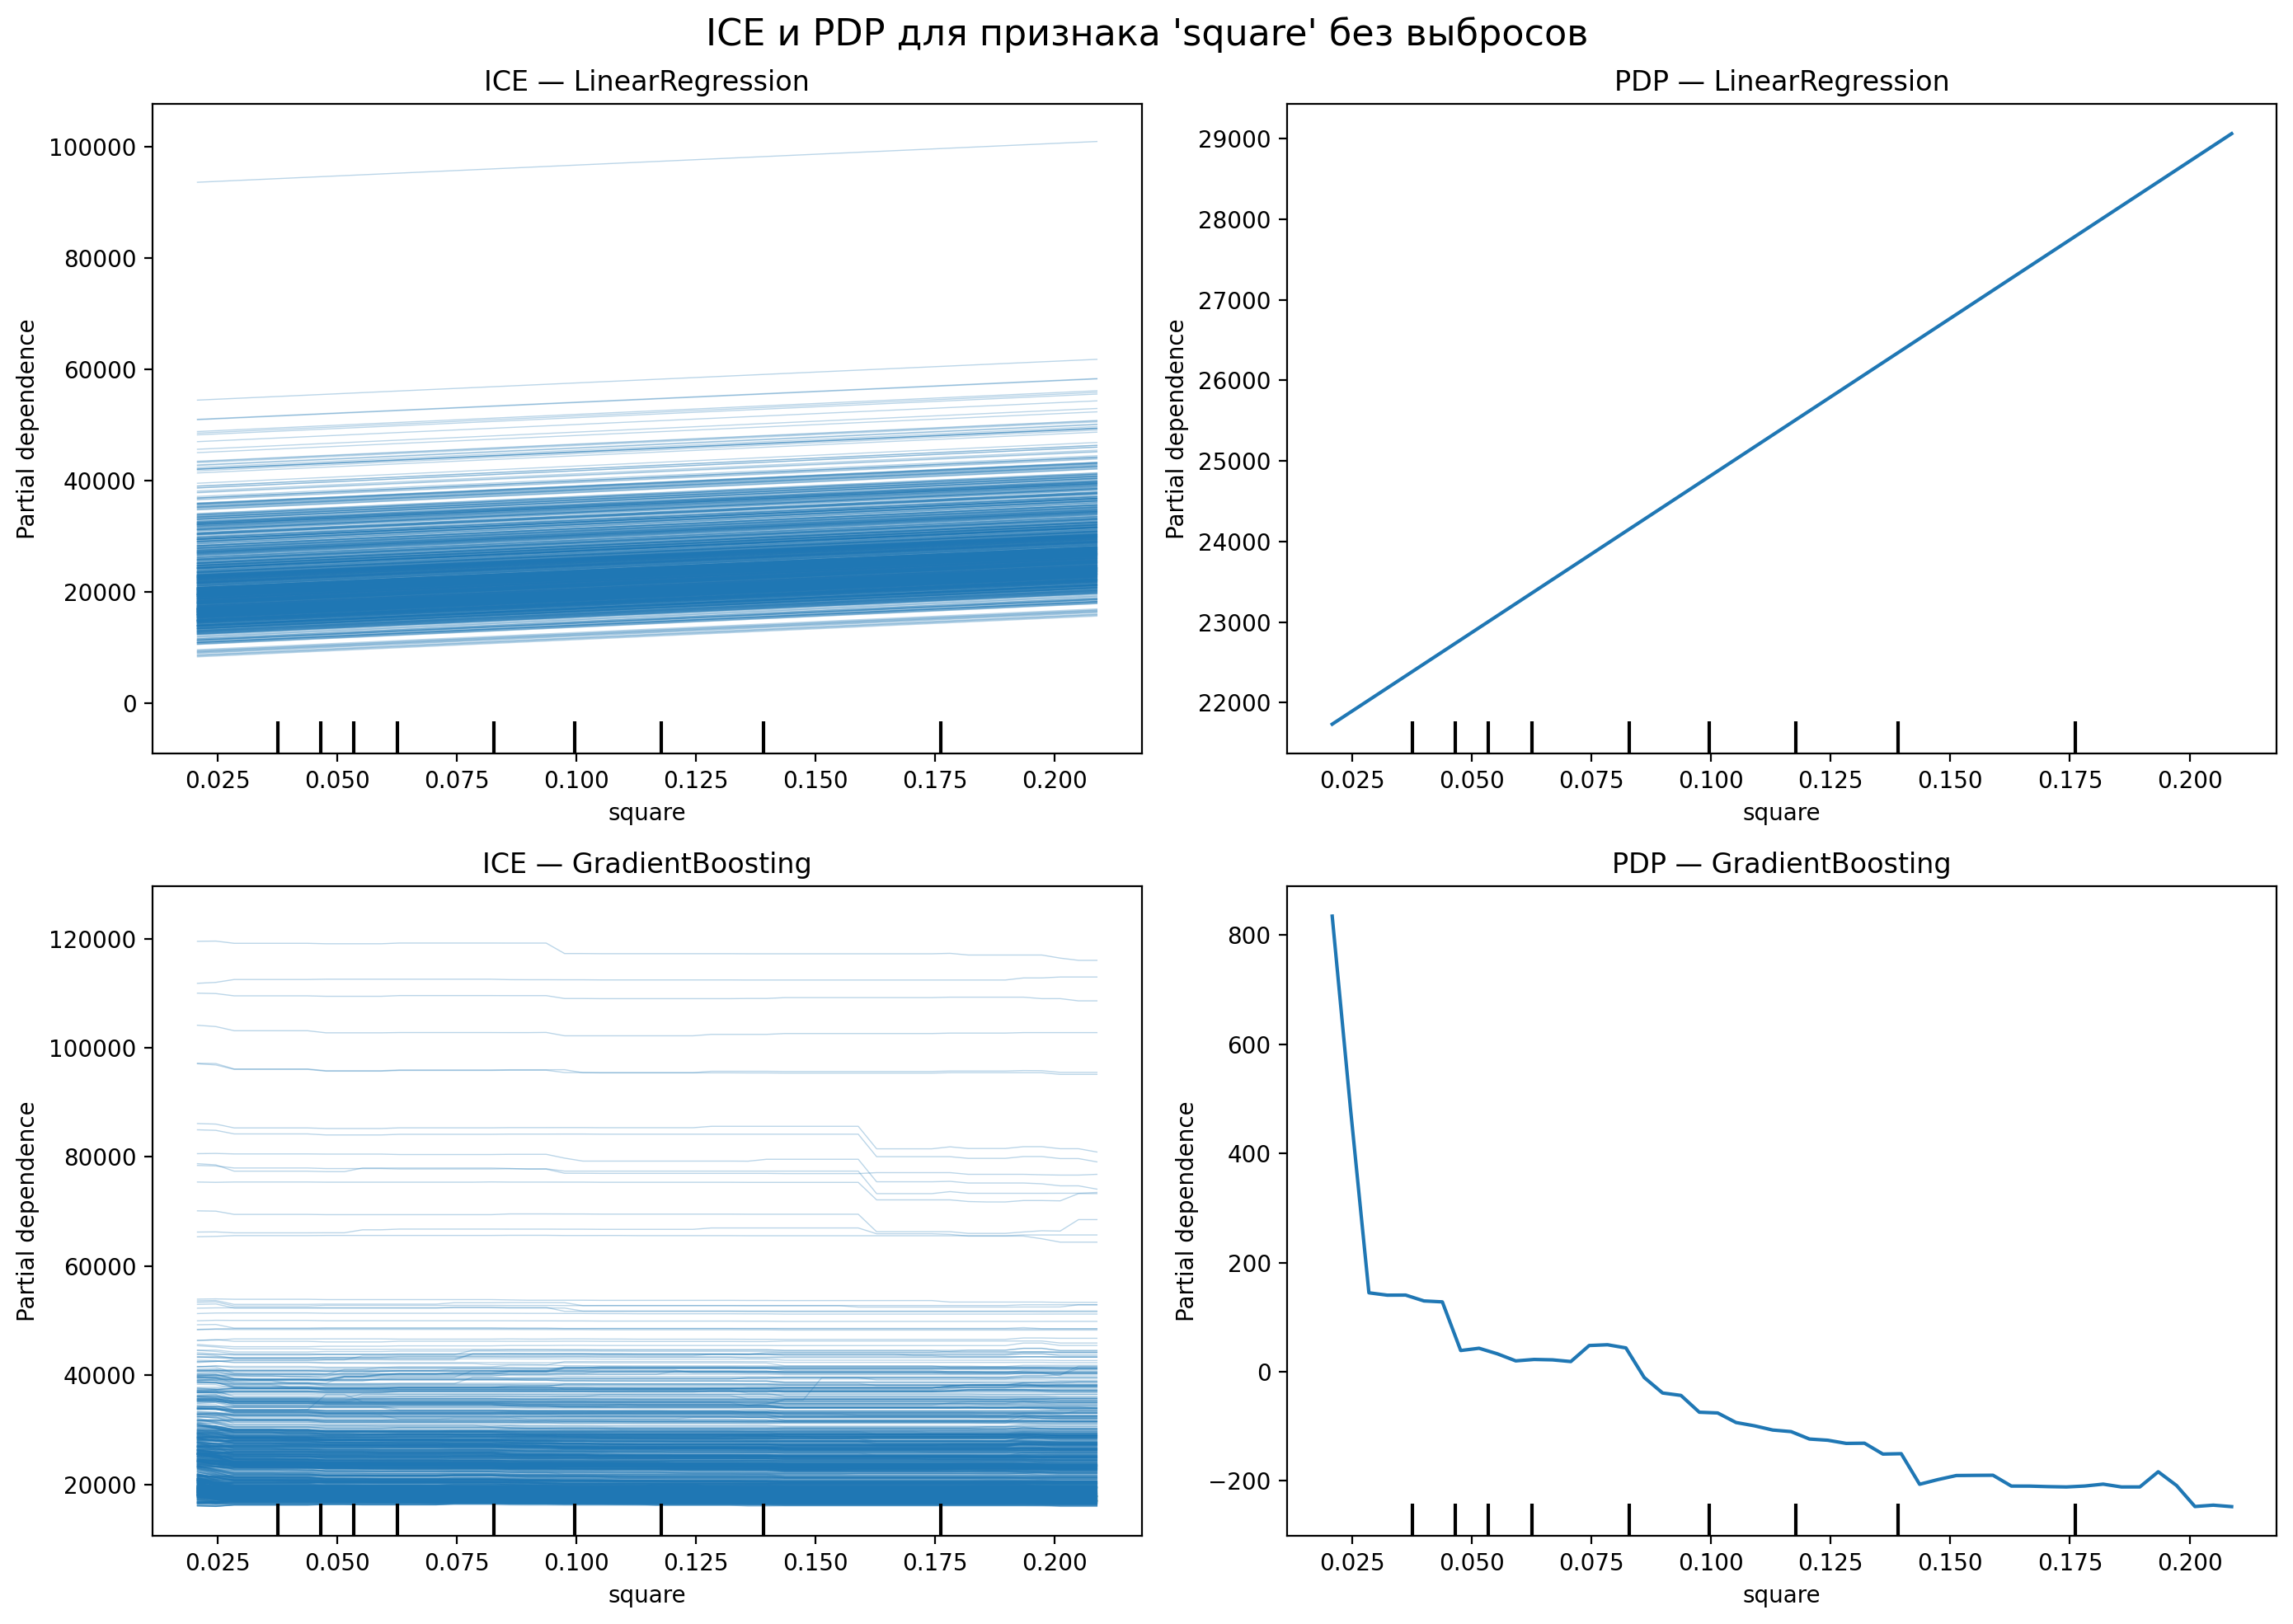

Выбросы: [-1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0, 1.5, 2.0]
Диапазон признака после добавления выбросов: min = -1.00, max = 2.00


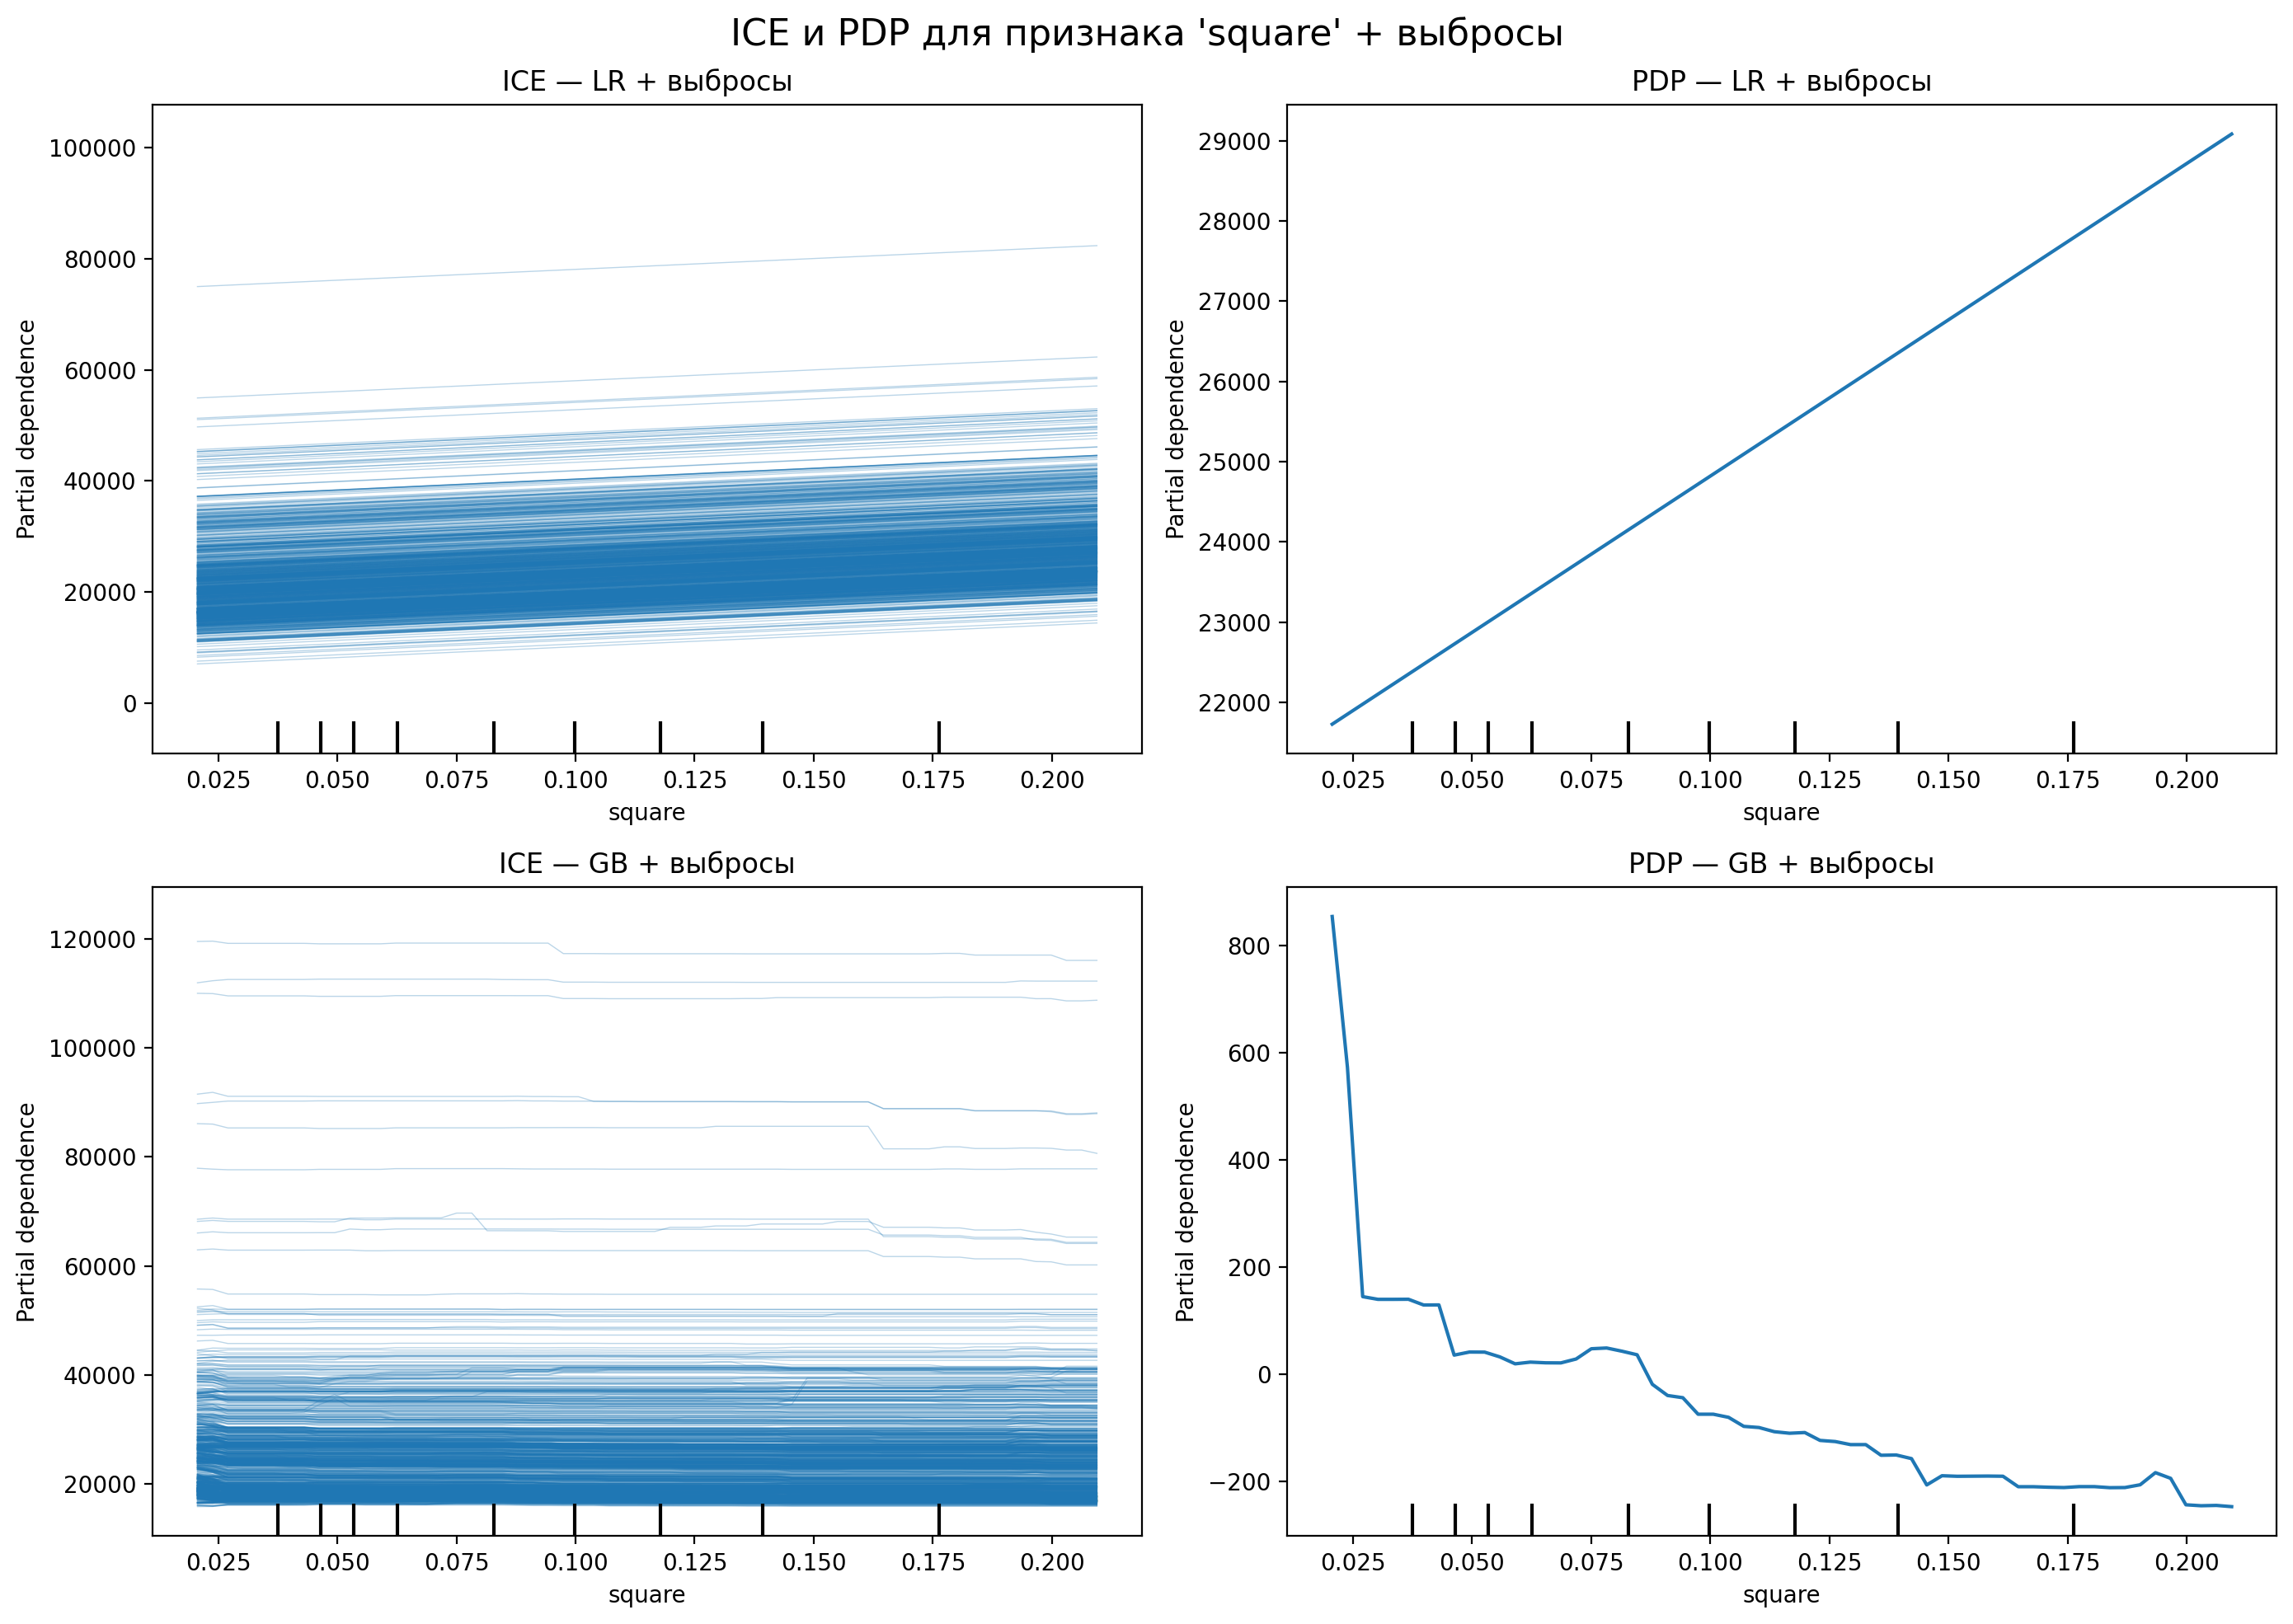

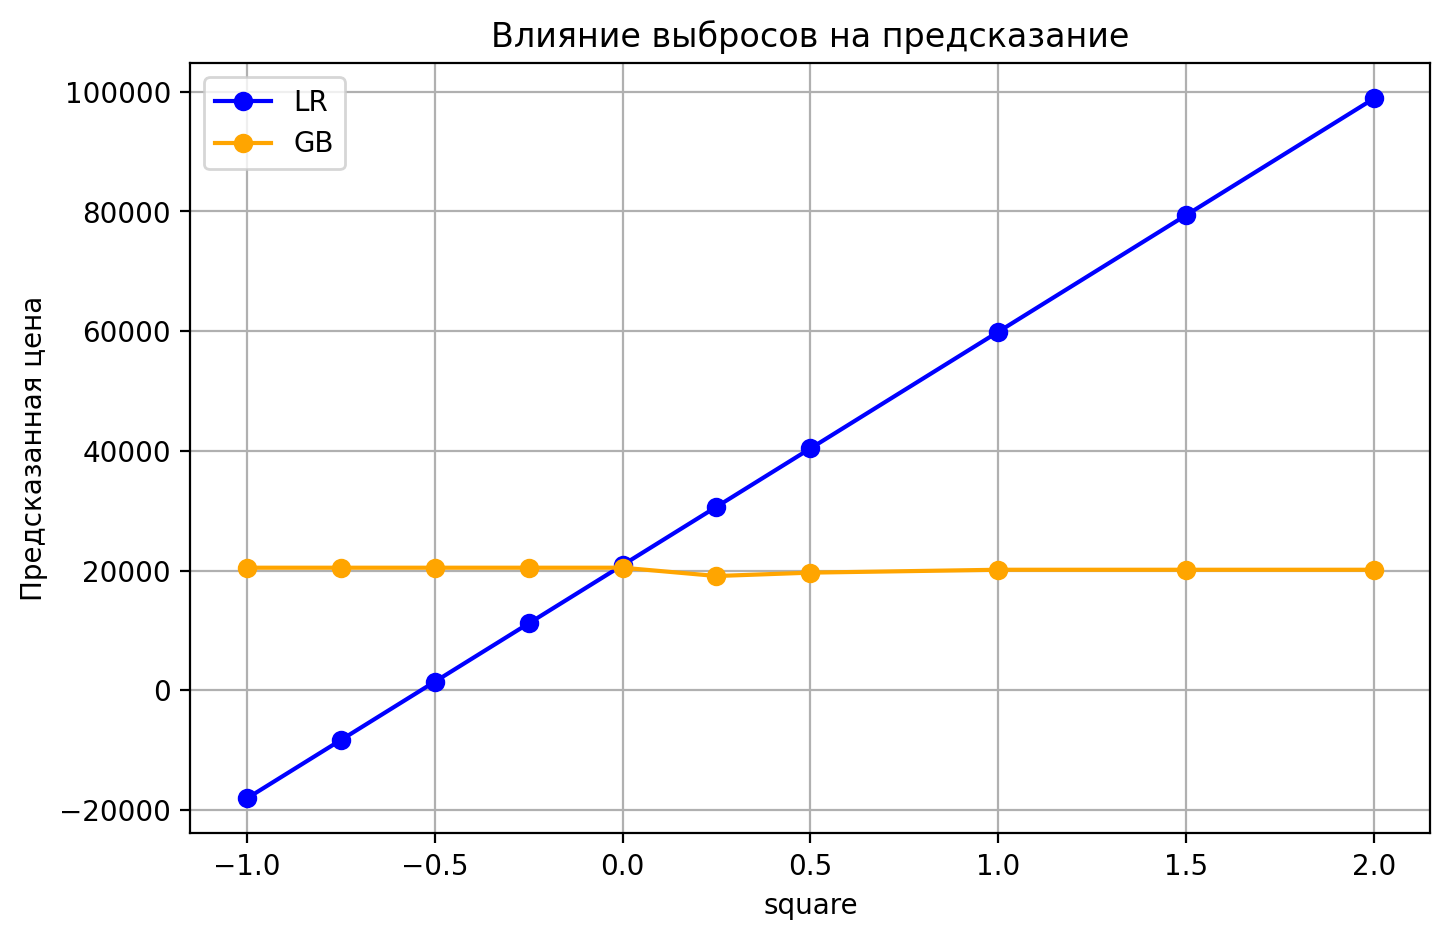

In [15]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd
import numpy as np

np.random.seed(42)

feature = 'square'
print(f"Выбранный признак: {feature}")

mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)
X_test_mm_df = pd.DataFrame(X_test_mm, columns=X_train.columns)

lr_mm = LinearRegression().fit(X_train_mm, y_train)
gb_mm = GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=100).fit(X_train_mm, y_train)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("ICE и PDP для признака 'square' без выбросов", fontsize=16)

PartialDependenceDisplay.from_estimator(lr_mm, X_test_mm_df, [feature], kind='individual', ax=axes[0,0], grid_resolution=50)
axes[0,0].set_title("ICE — LinearRegression")
PartialDependenceDisplay.from_estimator(lr_mm, X_test_mm_df, [feature], kind='average', ax=axes[0,1], grid_resolution=50)
axes[0,1].set_title("PDP — LinearRegression")
PartialDependenceDisplay.from_estimator(gb_mm, X_test_mm_df, [feature], kind='individual', ax=axes[1,0], grid_resolution=50)
axes[1,0].set_title("ICE — GradientBoosting")
PartialDependenceDisplay.from_estimator(gb_mm, X_test_mm_df, [feature], kind='average', ax=axes[1,1], grid_resolution=50)
axes[1,1].set_title("PDP — GradientBoosting")

plt.tight_layout()
plt.show()

values_to_test = [-1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0, 1.5, 2.0]
print(f"Выбросы: {values_to_test}")

X_out_mm_df = X_test_mm_df.copy()
feat_idx = X_out_mm_df.columns.get_loc(feature)

for i, val in enumerate(values_to_test):
    X_out_mm_df.iloc[i, feat_idx] = val

print(f"Диапазон признака после добавления выбросов: "f"min = {X_out_mm_df[feature].min():.2f}, max = {X_out_mm_df[feature].max():.2f}")

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle("ICE и PDP для признака 'square' + выбросы", fontsize=16)

PartialDependenceDisplay.from_estimator(lr_mm, X_out_mm_df, [feature], kind='individual', ax=axes2[0,0], grid_resolution=60)
axes2[0,0].set_title("ICE — LR + выбросы")
PartialDependenceDisplay.from_estimator(lr_mm, X_out_mm_df, [feature], kind='average', ax=axes2[0,1], grid_resolution=60)
axes2[0,1].set_title("PDP — LR + выбросы")
PartialDependenceDisplay.from_estimator(gb_mm, X_out_mm_df, [feature], kind='individual', ax=axes2[1,0], grid_resolution=60)
axes2[1,0].set_title("ICE — GB + выбросы")
PartialDependenceDisplay.from_estimator(gb_mm, X_out_mm_df, [feature], kind='average', ax=axes2[1,1], grid_resolution=60)
axes2[1,1].set_title("PDP — GB + выбросы")


for ax in axes2.flatten():
    ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.8)
    ax.axvline(1, color='red', linestyle='--', linewidth=2, alpha=0.8)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

mean_row = X_test_mm_df.mean().values.reshape(1, -1)
X_test_points = np.tile(mean_row, (len(values_to_test), 1))
X_test_points[:, feat_idx] = values_to_test

pred_lr = lr_mm.predict(X_test_points)
pred_gb = gb_mm.predict(X_test_points)

plt.figure(figsize=(8, 5))
plt.plot(values_to_test, pred_lr, 'o-', label='LR', color='blue')
plt.plot(values_to_test, pred_gb, 'o-', label='GB', color='orange')
plt.xlabel('square')
plt.ylabel('Предсказанная цена')
plt.title('Влияние выбросов на предсказание')
plt.legend()
plt.grid(True)
plt.show()

### Анализ ICE и PDP для признака `square`

#### Поведение моделей в пределах обучающего диапазона

- Линейная регрессия (LR) 
  - PDP — идеальная прямая линия с положительным наклоном. Модель считает, что цена линейно и сильно растёт с увеличением площади.  
  - ICE — почти все индивидуальные линии параллельны и близки к средней, эффект площади практически одинаков для большинства объектов, сильных нелинейных взаимодействий с другими признаками почти нет.

- Градиентный бустинг (GB)
  - PDP — нелинейная, убывающая зависимость (с резким падением в начале и дальнейшим медленным снижением).  
  - ICE — индивидуальные траектории довольно разнородны, но в целом повторяют среднюю тенденцию.  

#### Что происходит при экстраполяции

- Линейная регрессия
  - Продолжает ту же самую прямую линию далеко за пределы [0, 1].  
  - На графике влияния выбросов — чёткая линейная зависимость даже при square –1.0 и 2.0.  
  Значит очень чувствительна к значениям вне диапазона обучения: экстремально низкие и высокие предсказания.  

- Градиентный бустинг  
  - PDP и ICE практически не реагируют на значения за пределами [0, 1].  
  - На графике «Влияние выбросов» — предсказание почти горизонтально (замерло) при square < 0 и > 1.  
  Значит устойчива к экстраполяции. Деревья решений просто отправляют такие объекты в крайние листья — дальнейшее изменение признака уже не влияет на предсказание.

## Задание 2.1 (*) 1 балл
Проанализируйте также еще один признак

Выбранный признак: floor


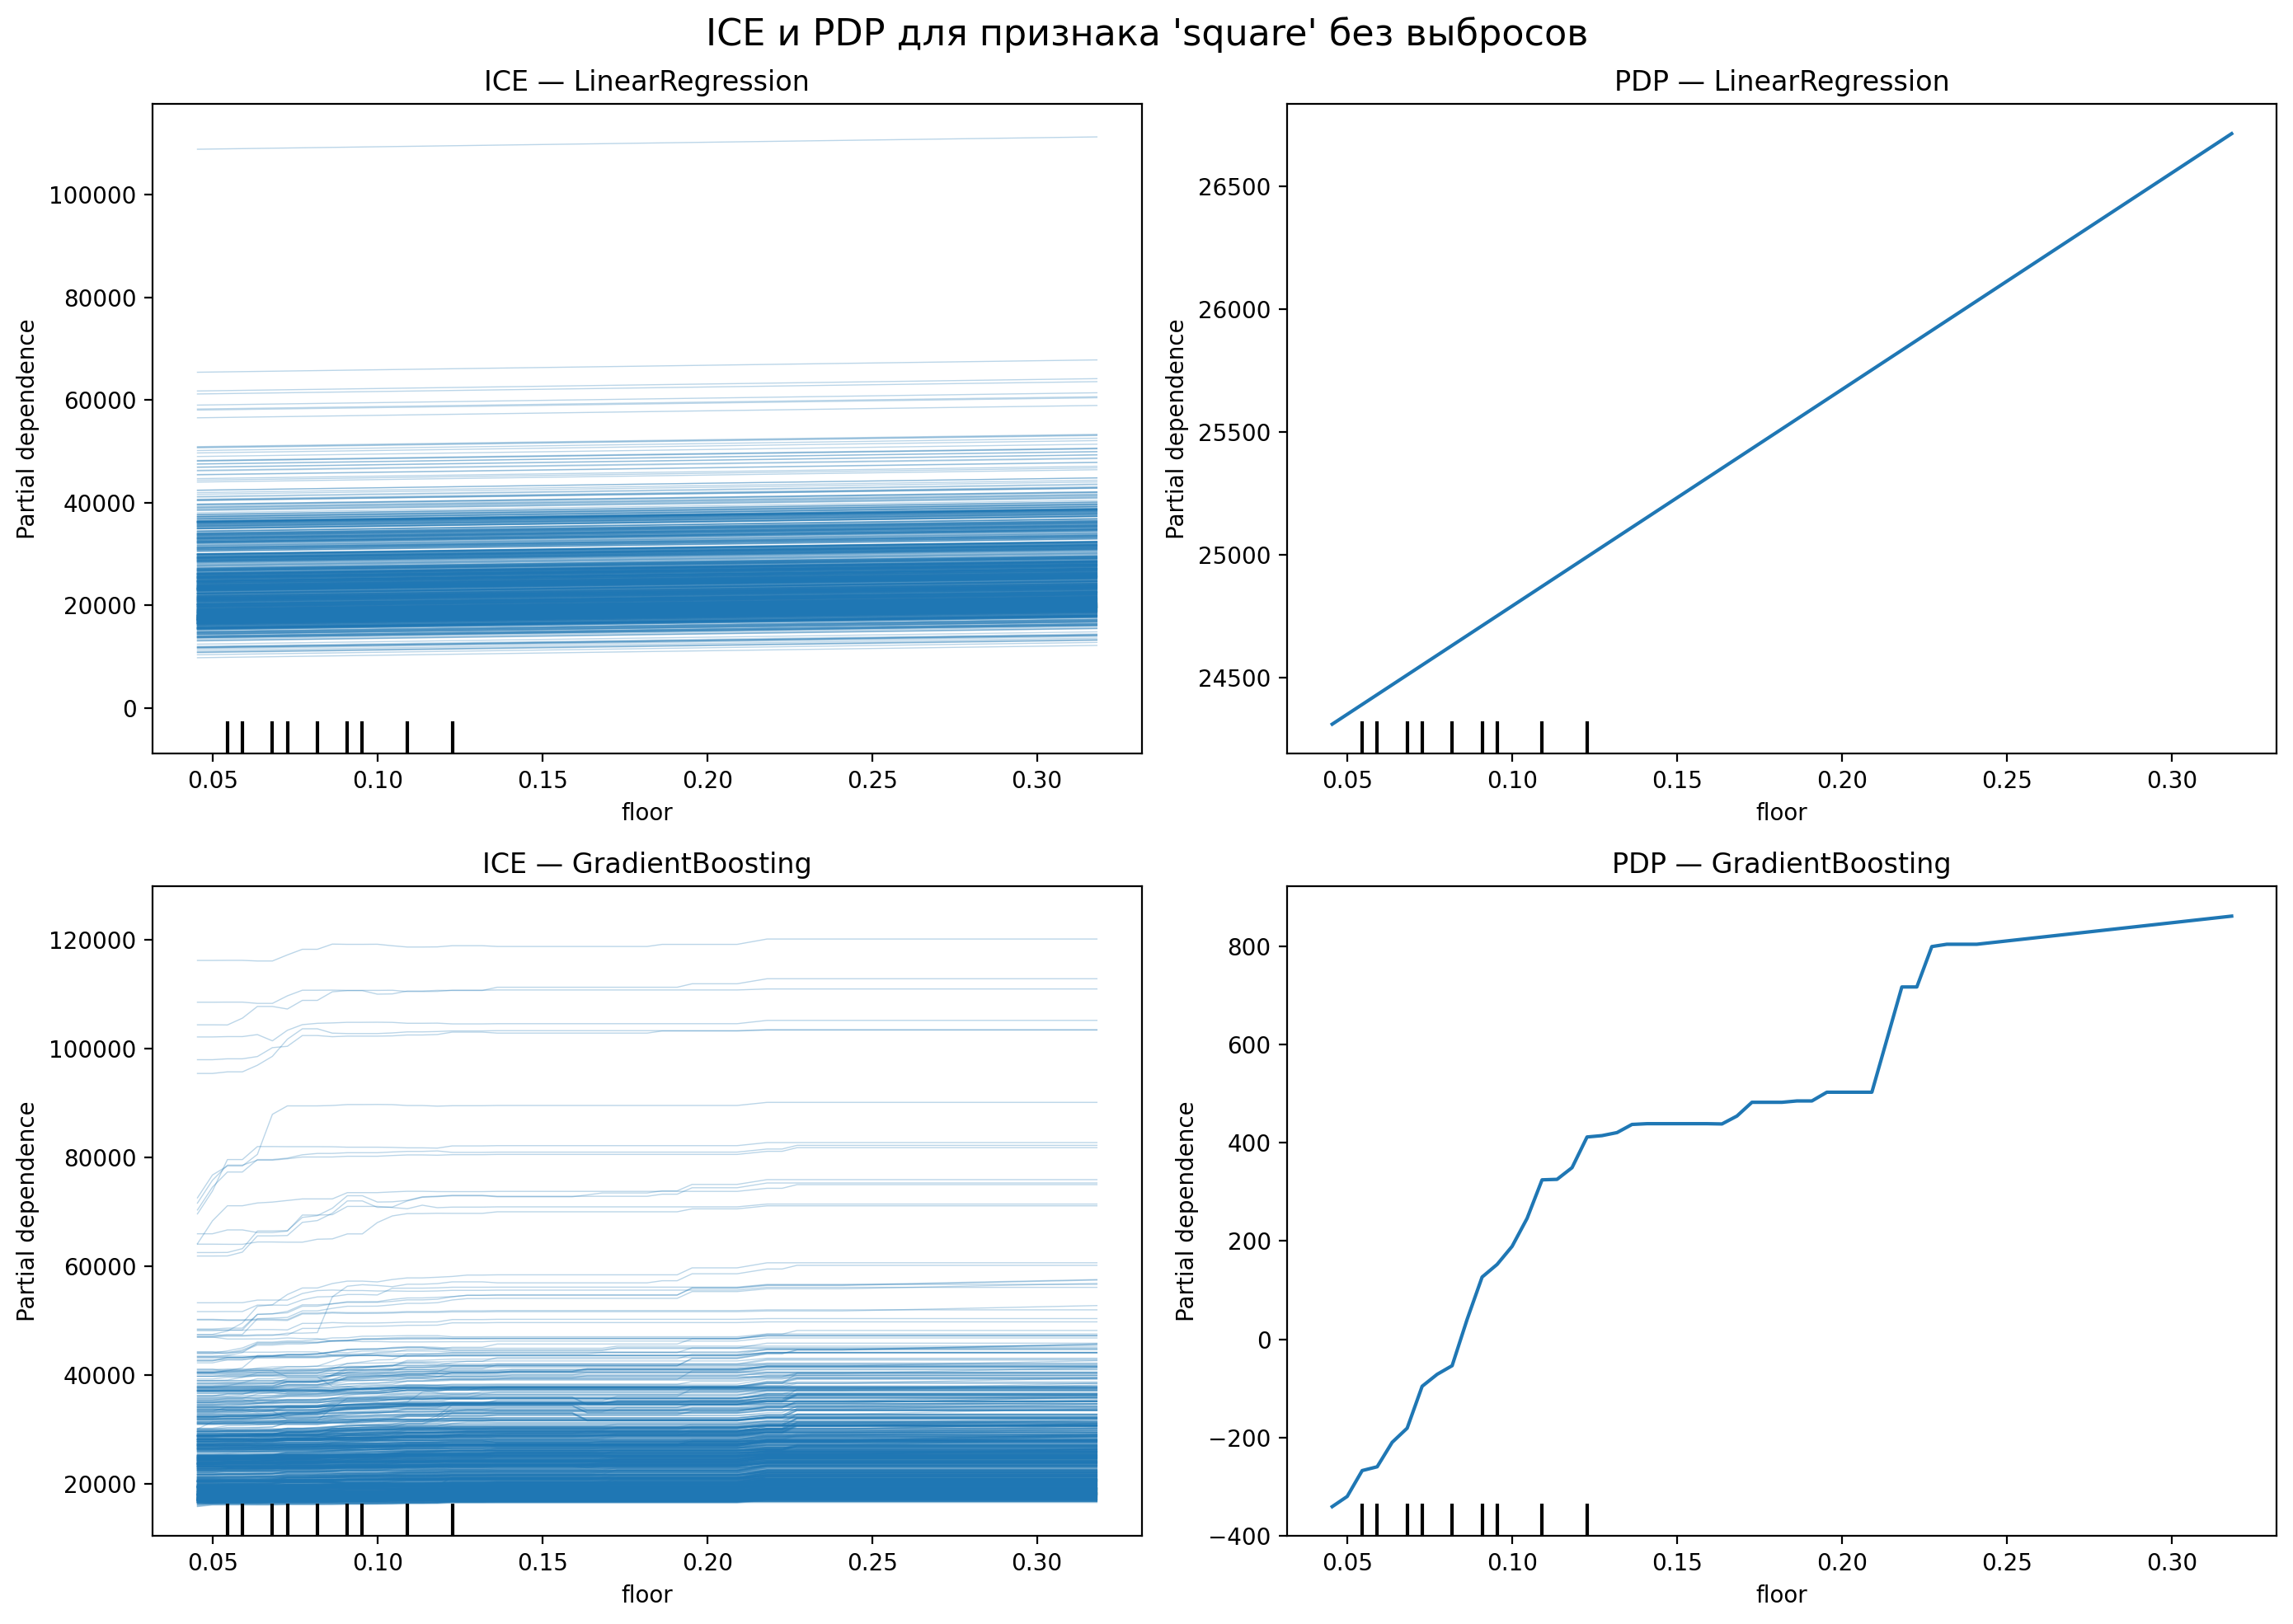

Выбросы: [-1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0, 1.5, 2.0]
Диапазон признака после добавления выбросов: min = -1.00, max = 2.00


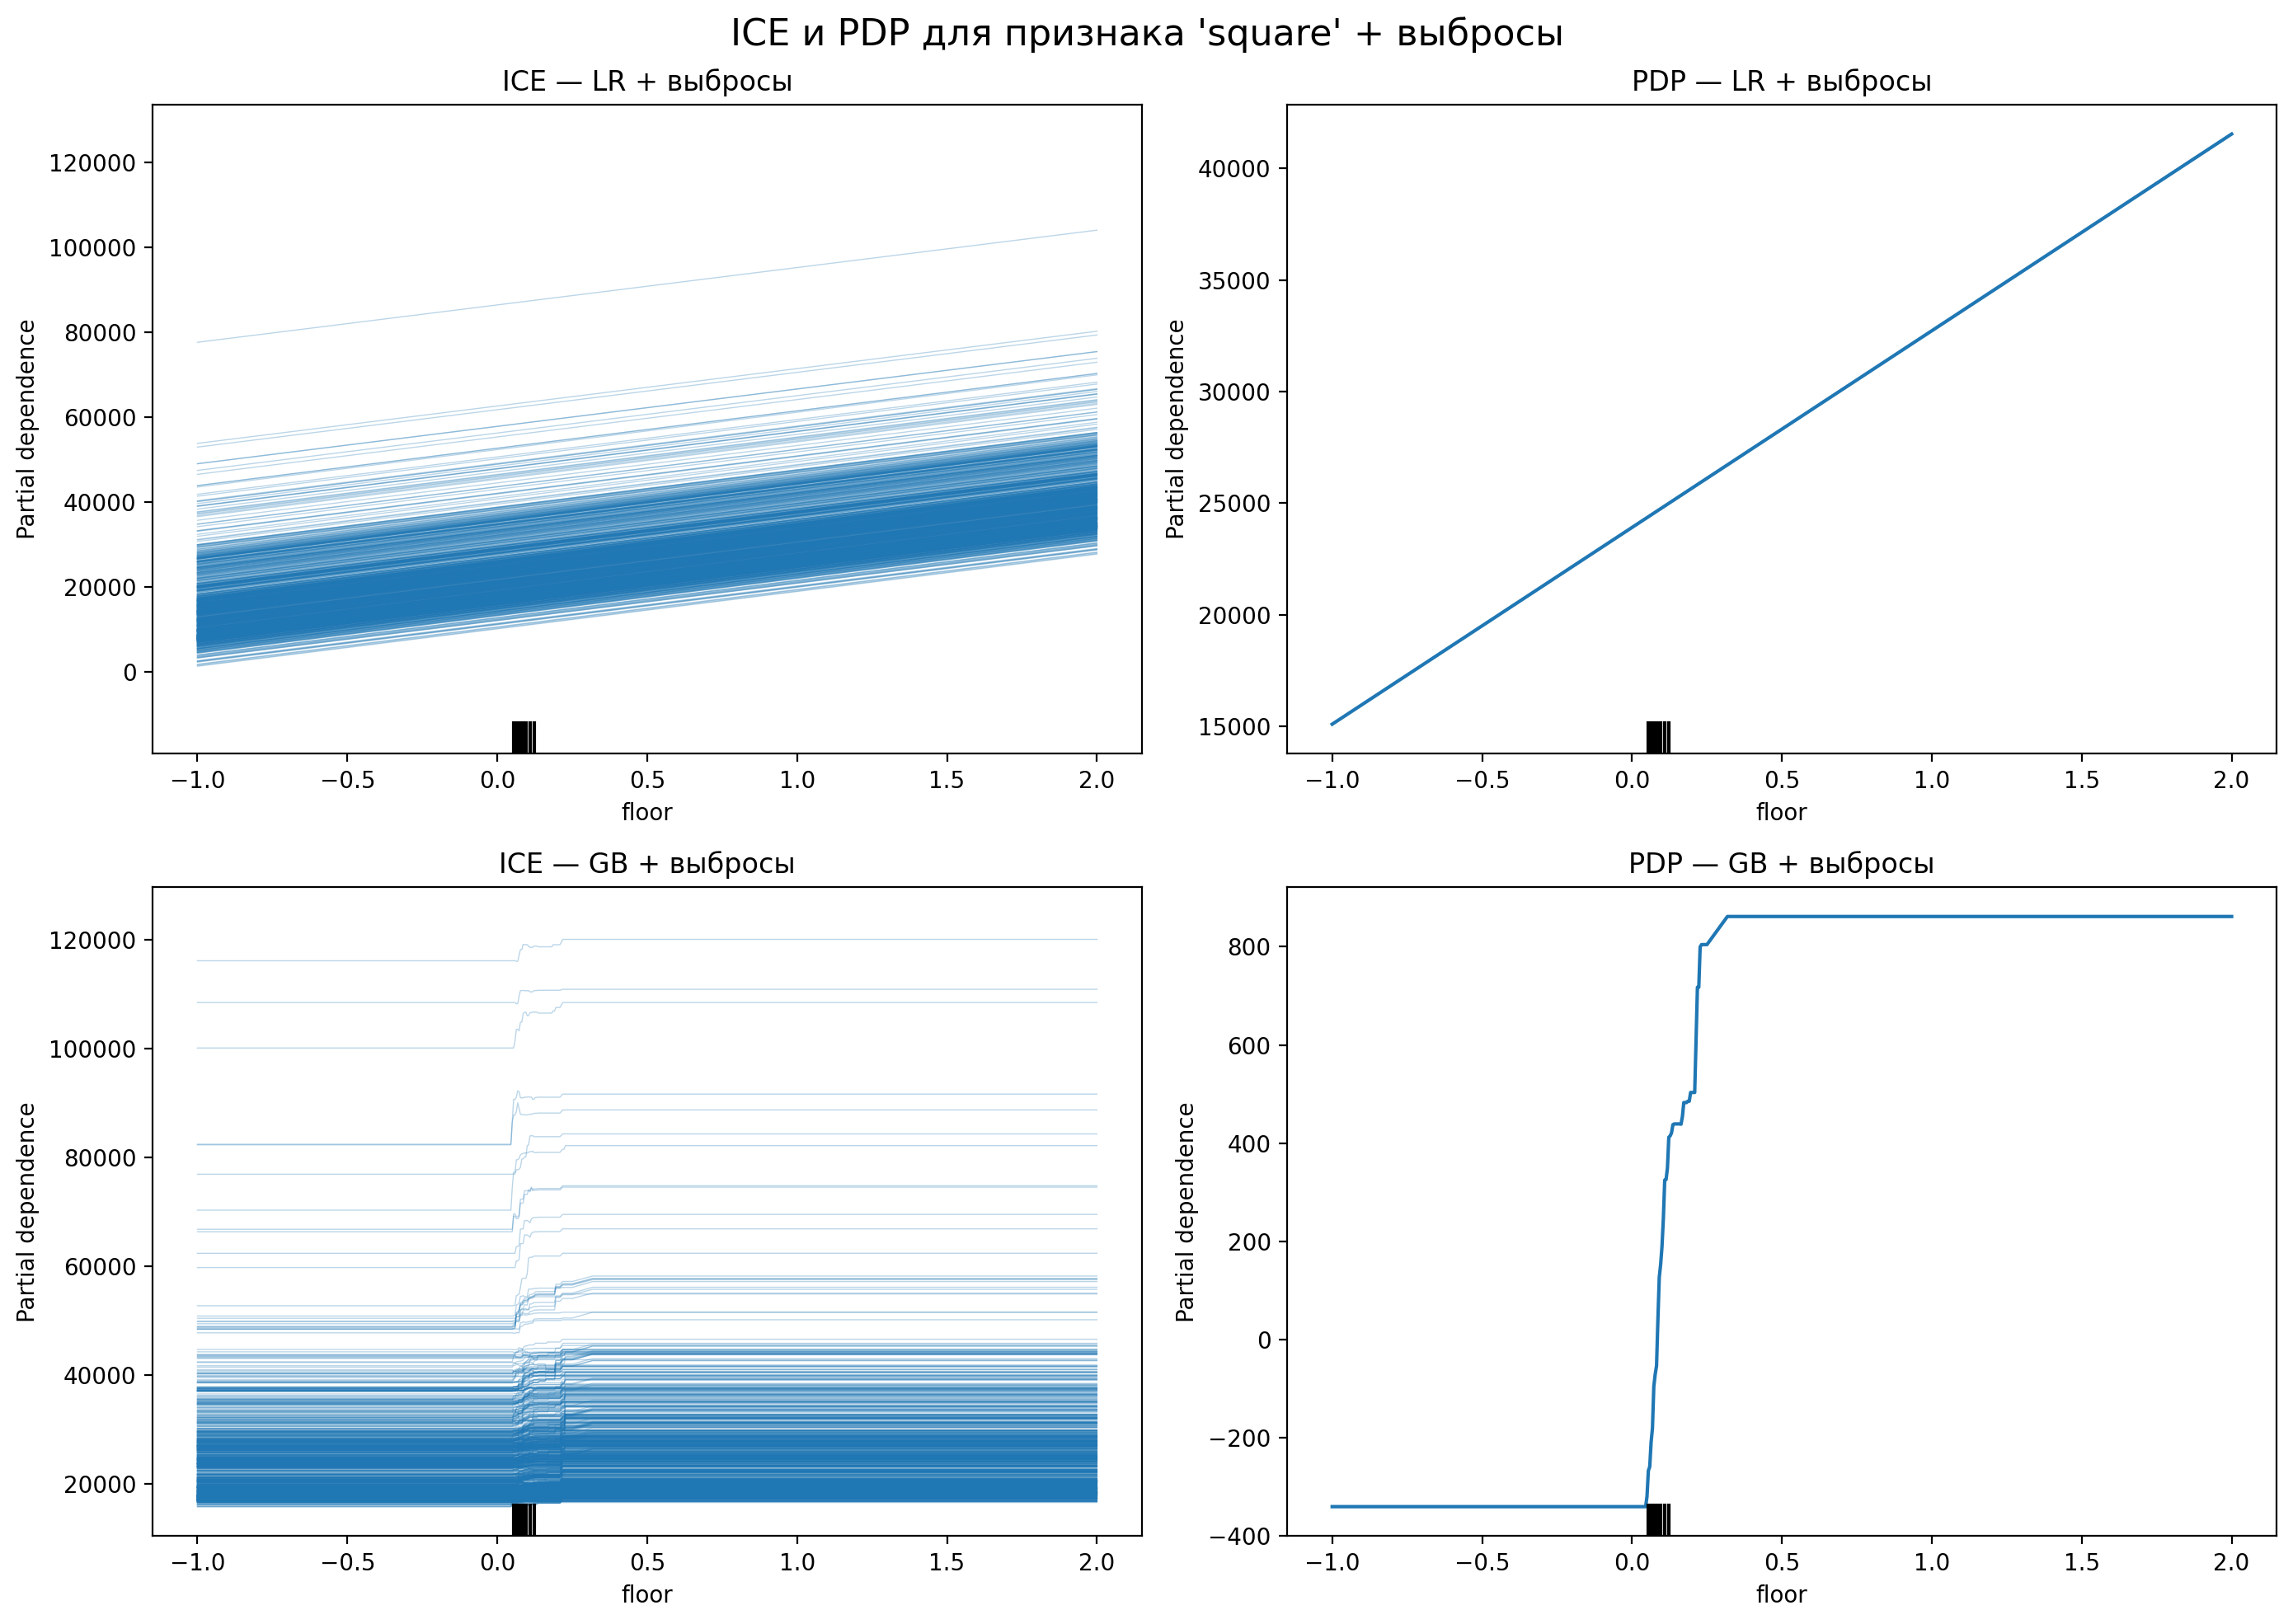

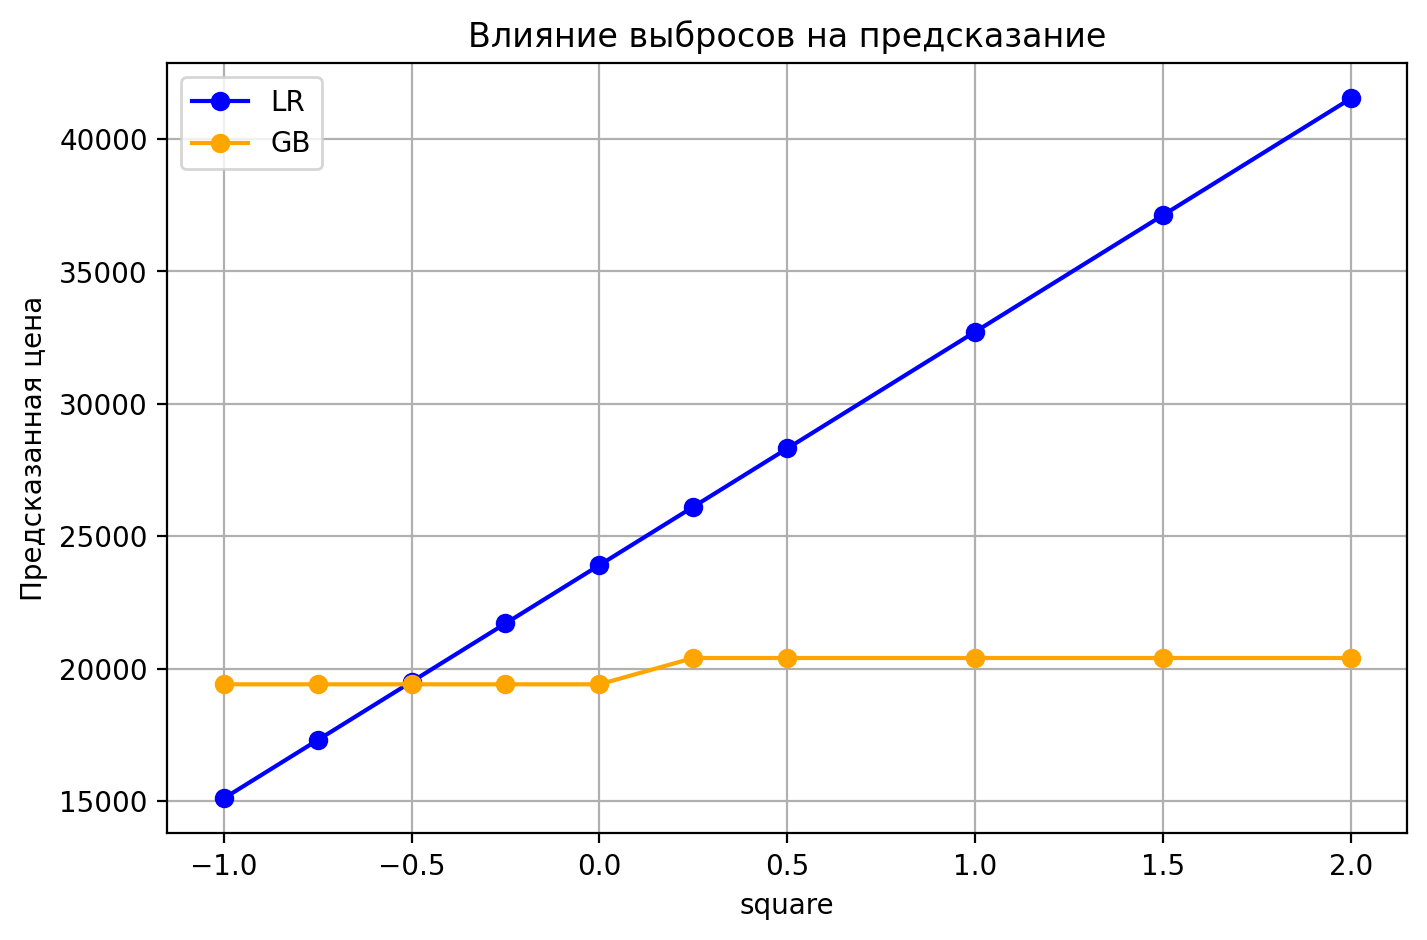

In [16]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd
import numpy as np

np.random.seed(42)

feature = 'floor'
print(f"Выбранный признак: {feature}")

mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)
X_test_mm_df = pd.DataFrame(X_test_mm, columns=X_train.columns)

lr_mm = LinearRegression().fit(X_train_mm, y_train)
gb_mm = GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=100).fit(X_train_mm, y_train)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("ICE и PDP для признака 'square' без выбросов", fontsize=16)

PartialDependenceDisplay.from_estimator(lr_mm, X_test_mm_df, [feature], kind='individual', ax=axes[0,0], grid_resolution=50)
axes[0,0].set_title("ICE — LinearRegression")
PartialDependenceDisplay.from_estimator(lr_mm, X_test_mm_df, [feature], kind='average', ax=axes[0,1], grid_resolution=50)
axes[0,1].set_title("PDP — LinearRegression")
PartialDependenceDisplay.from_estimator(gb_mm, X_test_mm_df, [feature], kind='individual', ax=axes[1,0], grid_resolution=50)
axes[1,0].set_title("ICE — GradientBoosting")
PartialDependenceDisplay.from_estimator(gb_mm, X_test_mm_df, [feature], kind='average', ax=axes[1,1], grid_resolution=50)
axes[1,1].set_title("PDP — GradientBoosting")

plt.tight_layout()
plt.show()

values_to_test = [-1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0, 1.5, 2.0]
print(f"Выбросы: {values_to_test}")

X_out_mm_df = X_test_mm_df.copy()
feat_idx = X_out_mm_df.columns.get_loc(feature)

for i, val in enumerate(values_to_test):
    X_out_mm_df.iloc[i, feat_idx] = val

print(f"Диапазон признака после добавления выбросов: "f"min = {X_out_mm_df[feature].min():.2f}, max = {X_out_mm_df[feature].max():.2f}")

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle("ICE и PDP для признака 'square' + выбросы", fontsize=16)

PartialDependenceDisplay.from_estimator(lr_mm, X_out_mm_df, [feature], kind='individual', ax=axes2[0,0], grid_resolution=60)
axes2[0,0].set_title("ICE — LR + выбросы")
PartialDependenceDisplay.from_estimator(lr_mm, X_out_mm_df, [feature], kind='average', ax=axes2[0,1], grid_resolution=60)
axes2[0,1].set_title("PDP — LR + выбросы")
PartialDependenceDisplay.from_estimator(gb_mm, X_out_mm_df, [feature], kind='individual', ax=axes2[1,0], grid_resolution=60)
axes2[1,0].set_title("ICE — GB + выбросы")
PartialDependenceDisplay.from_estimator(gb_mm, X_out_mm_df, [feature], kind='average', ax=axes2[1,1], grid_resolution=60)
axes2[1,1].set_title("PDP — GB + выбросы")


for ax in axes2.flatten():
    ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.8)
    ax.axvline(1, color='red', linestyle='--', linewidth=2, alpha=0.8)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

mean_row = X_test_mm_df.mean().values.reshape(1, -1)
X_test_points = np.tile(mean_row, (len(values_to_test), 1))
X_test_points[:, feat_idx] = values_to_test

pred_lr = lr_mm.predict(X_test_points)
pred_gb = gb_mm.predict(X_test_points)

plt.figure(figsize=(8, 5))
plt.plot(values_to_test, pred_lr, 'o-', label='LR', color='blue')
plt.plot(values_to_test, pred_gb, 'o-', label='GB', color='orange')
plt.xlabel('square')
plt.ylabel('Предсказанная цена')
plt.title('Влияние выбросов на предсказание')
plt.legend()
plt.grid(True)
plt.show()

### Анализ ICE и PDP для признака floor

#### Поведение моделей в пределах обучающего диапазона

- Линейная регрессия (LR)
    - PDP — идеальная прямая линия с положительным наклоном. Модель трактует каждый дополнительный этаж как одинаково увеличивающий цену, без учёта насыщения.
    - ICE — большинство индивидуальных линий почти параллельны и близки к средней. Влияние этажа довольно однородно по выборке, сильных взаимодействий с другими признаками почти не наблюдается.

- Градиентный бустинг (GB)
    - PDP — выраженная нелинейная зависимость: быстрый рост в нижней части диапазона (до 0.20 – 0.25), затем резкое замедление и практически плато.
    - ICE — линии значительно разнородны: у части объектов наблюдается сильный прирост цены с этажом, у других — почти горизонтальное поведение уже после середины диапазона.
    Значит модель хорошо уловила типичную для рынка недвижимости картину: низкие этажи сильно дешевле, выше определённого уровня (12 – 16 этаж) дальнейший рост этажности почти не добавляет стоимости.

#### Что происходит при экстраполяции

- Линейная регрессия
    - Продолжает ту же прямую линию далеко за пределы [0, 1].
    - На графике влияния выбросов видна чёткая линейная зависимость вплоть до –1.0 и 2.0.
    Значит модель крайне чувствительна к значениям вне диапазона: при отрицательных этажах предсказывает нереалистично низкие цены, при очень высоких — экстремально завышенные.

- Градиентный бустинг
    - PDP и ICE практически не меняются за пределами оригинального диапазона.
    - На графике влияния выбросов предсказание почти горизонтально после +-0.3–0.5 (плато около 20 000).
    Значит модель устойчива к экстраполяции: деревья решений отправляют экстремальные значения в крайние листья — дальнейшее увеличение или уменьшение этажа уже почти не влияет на прогноз.

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории

Признак: square
Базовое значение (медиана по train): 51.25


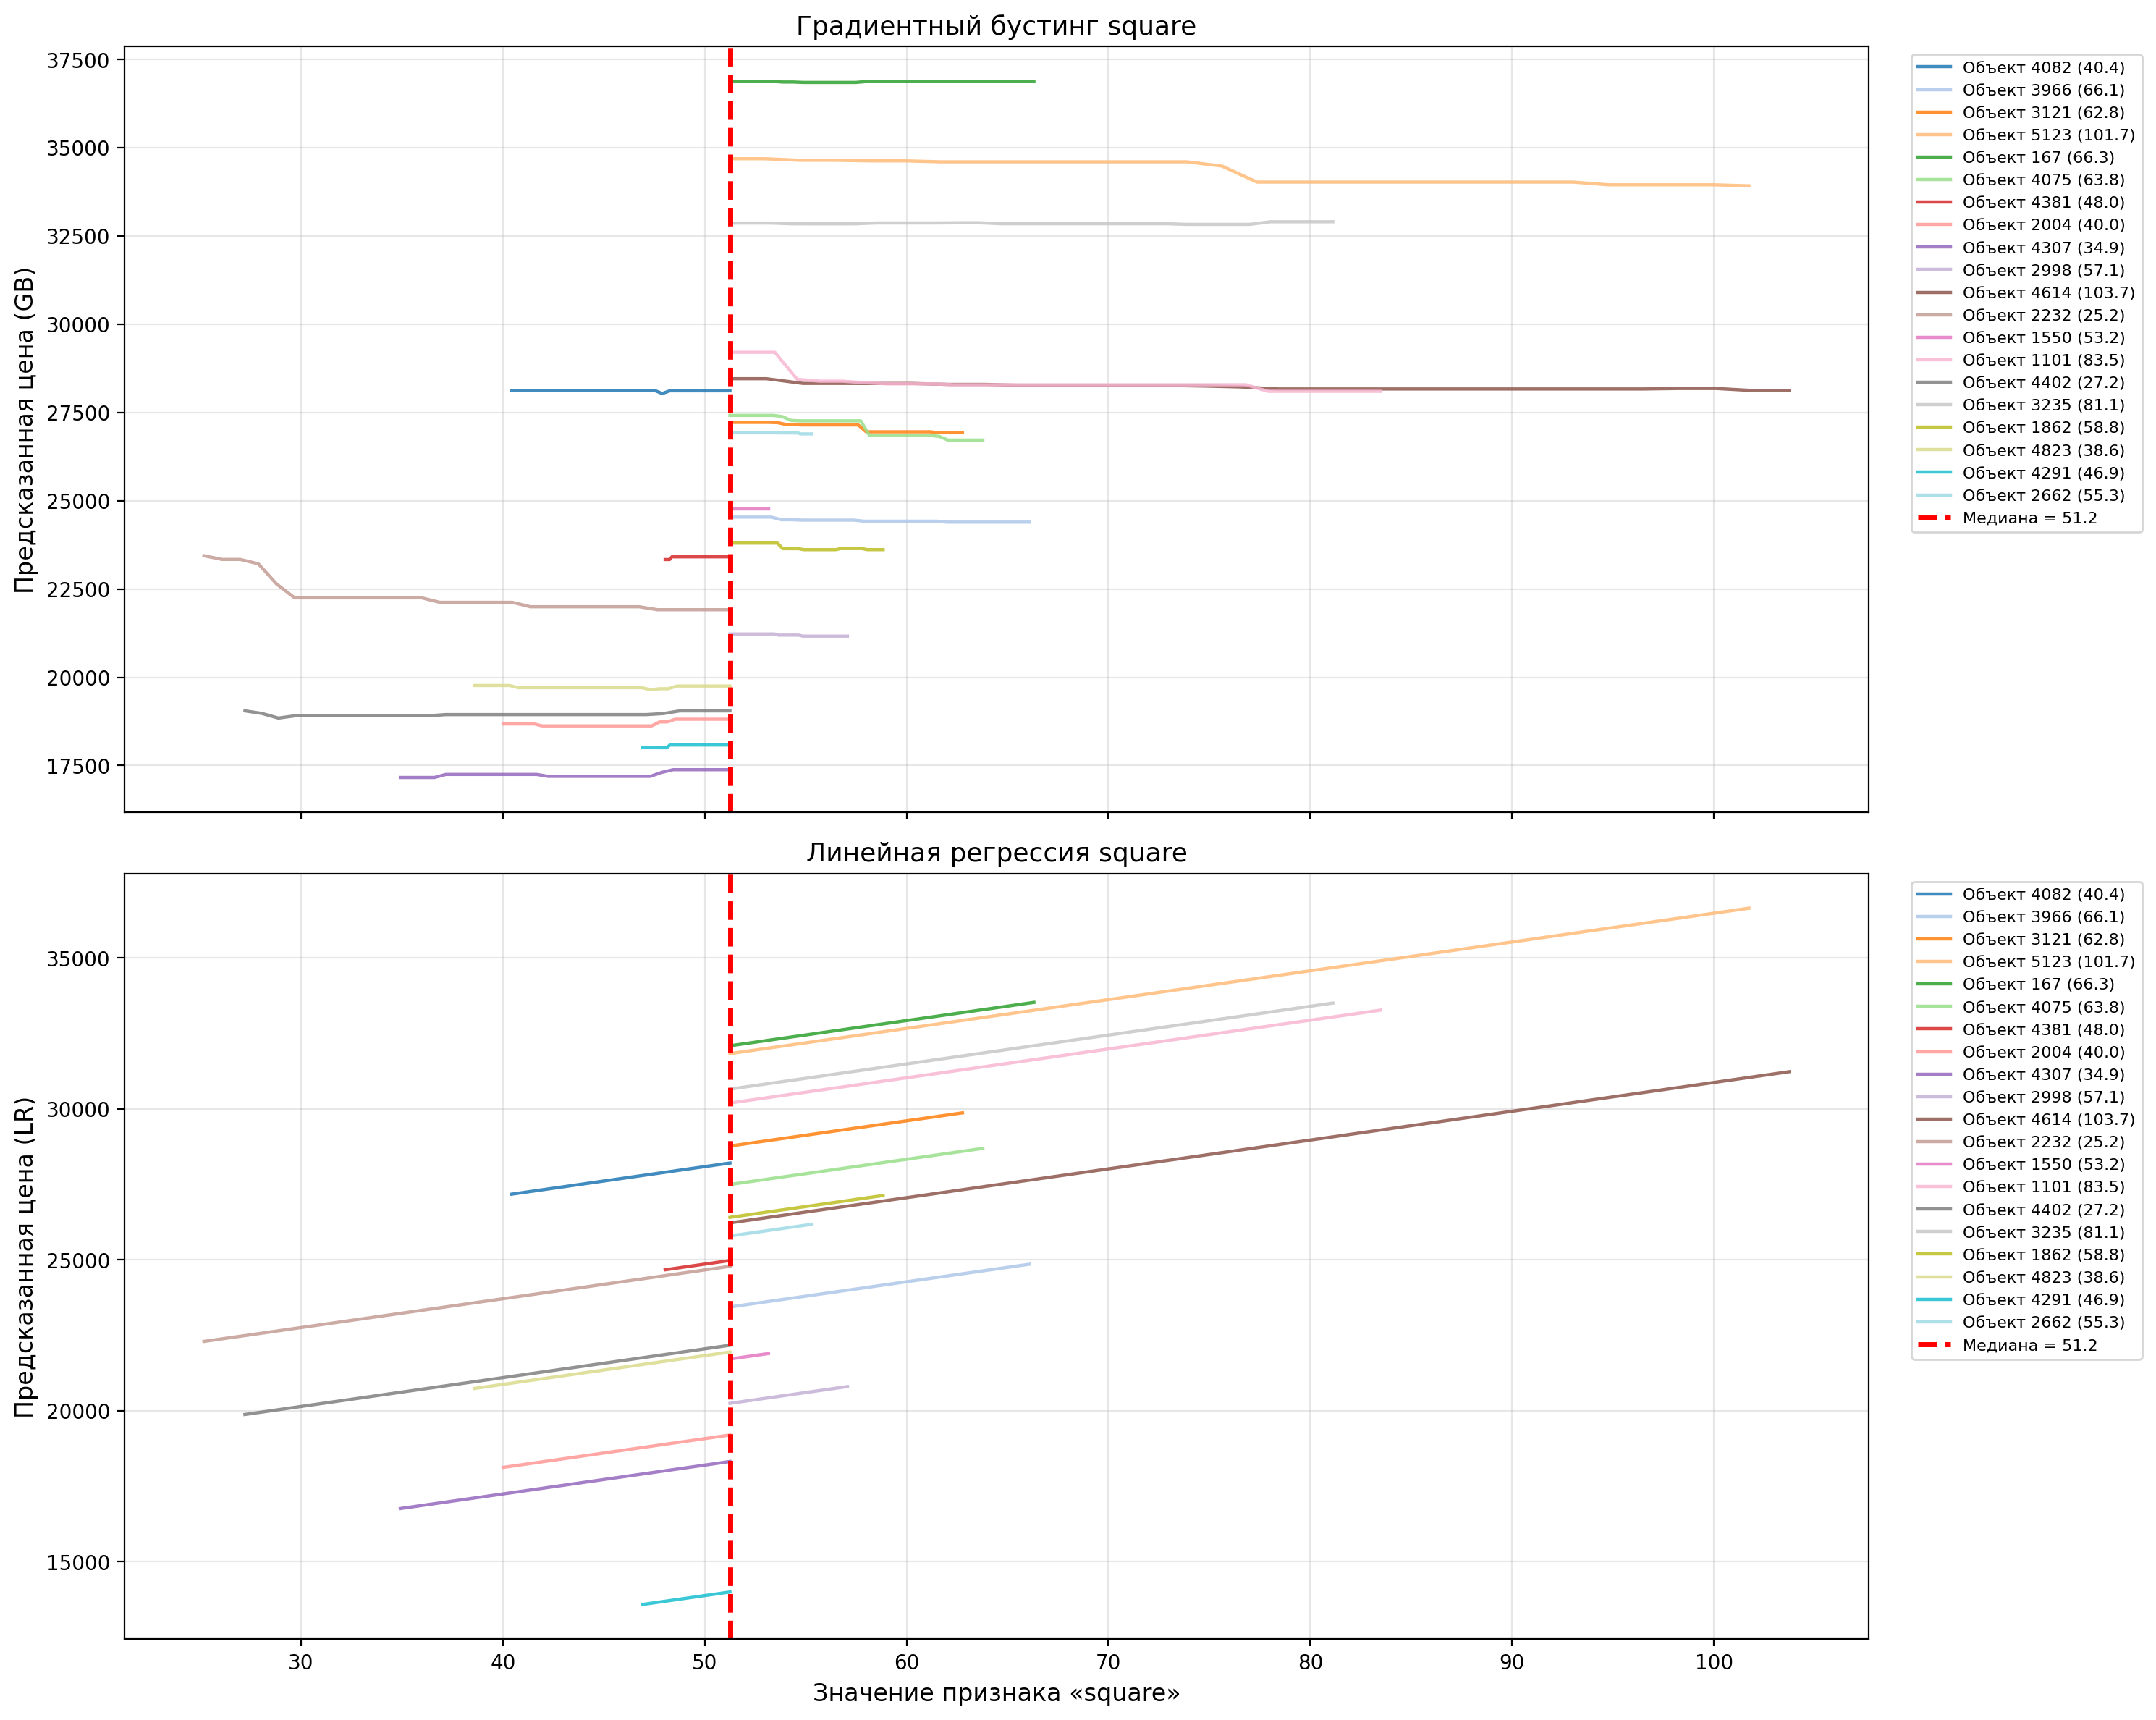

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

feature = 'square'
n_objects = 20
n_steps = 30
baseline = X_train[feature].median()

print(f"Признак: {feature}")
print(f"Базовое значение (медиана по train): {baseline:.2f}")

gb_raw = GradientBoostingRegressor(max_depth=5, n_estimators=100, random_state=42)
gb_raw.fit(X_train, y_train)

lr_raw = LinearRegression()
lr_raw.fit(X_train, y_train)

np.random.seed(42)
selected_idx = np.random.choice(len(X_test), n_objects, replace=False)
X_selected = X_test.iloc[selected_idx].copy().reset_index(drop=True)

fig, (ax_gb, ax_lr) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

colors = plt.cm.tab20(np.linspace(0, 1, n_objects))

for i in range(n_objects):
    row = X_selected.iloc[[i]].copy()
    current_val = row[feature].iloc[0]
    interp_vals = np.linspace(current_val, baseline, n_steps)
    
    pred_gb = []
    pred_lr = []
    
    for val in interp_vals:
        row_mod = row.copy()
        row_mod[feature] = val
        pred_gb.append(gb_raw.predict(row_mod)[0])
        pred_lr.append(lr_raw.predict(row_mod)[0])
    
    ax_gb.plot(interp_vals, pred_gb, color=colors[i], linewidth=1.6, alpha=0.85, label=f'Объект {selected_idx[i]} ({current_val:.1f})')
    
    ax_lr.plot(interp_vals, pred_lr, color=colors[i], linewidth=1.6, alpha=0.85, label=f'Объект {selected_idx[i]} ({current_val:.1f})')

ax_gb.axvline(baseline, color='red', linestyle='--', linewidth=2.5, label=f'Медиана = {baseline:.1f}')
ax_lr.axvline(baseline, color='red', linestyle='--', linewidth=2.5, label=f'Медиана = {baseline:.1f}')

ax_gb.set_ylabel('Предсказанная цена (GB)', fontsize=12)
ax_lr.set_ylabel('Предсказанная цена (LR)', fontsize=12)
ax_lr.set_xlabel(f'Значение признака «{feature}»', fontsize=12)

ax_gb.set_title(f'Градиентный бустинг {feature}', fontsize=13)
ax_lr.set_title(f'Линейная регрессия {feature}', fontsize=13)

ax_gb.grid(True, alpha=0.3)
ax_lr.grid(True, alpha=0.3)

ax_gb.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax_lr.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

- Градиентный бустинг показывает сильную, но нелинейную зависимость от площади: у очень больших квартир цена чаще всего даже растёт при уменьшении площади к медиане.
    - Видимо градиентный бустинг способен выучить нелинейные и немонотонные зависимости. На реальных данных о недвижимости может встречаться ситуация, когда очень большие квартиры стоят не намного дороже средних или даже хуже продаются, поэтому модель это увидела в данных и в некоторых областях начинает снижать предсказанную цену при дальнейшем росте площади (или наоборот повышать её при уменьшении с экстремально больших значений к более типичным 50–70 м²).
- Линейная регрессия даёт ожидаемую строго положительную и прямолинейную зависимость — чем больше площадь, тем выше предсказанная цена.

## Задание 3.1 (*) 1 балл
Проанализируйте также еще один признак

Признак: floor
Базовое значение (медиана по train): 9.00


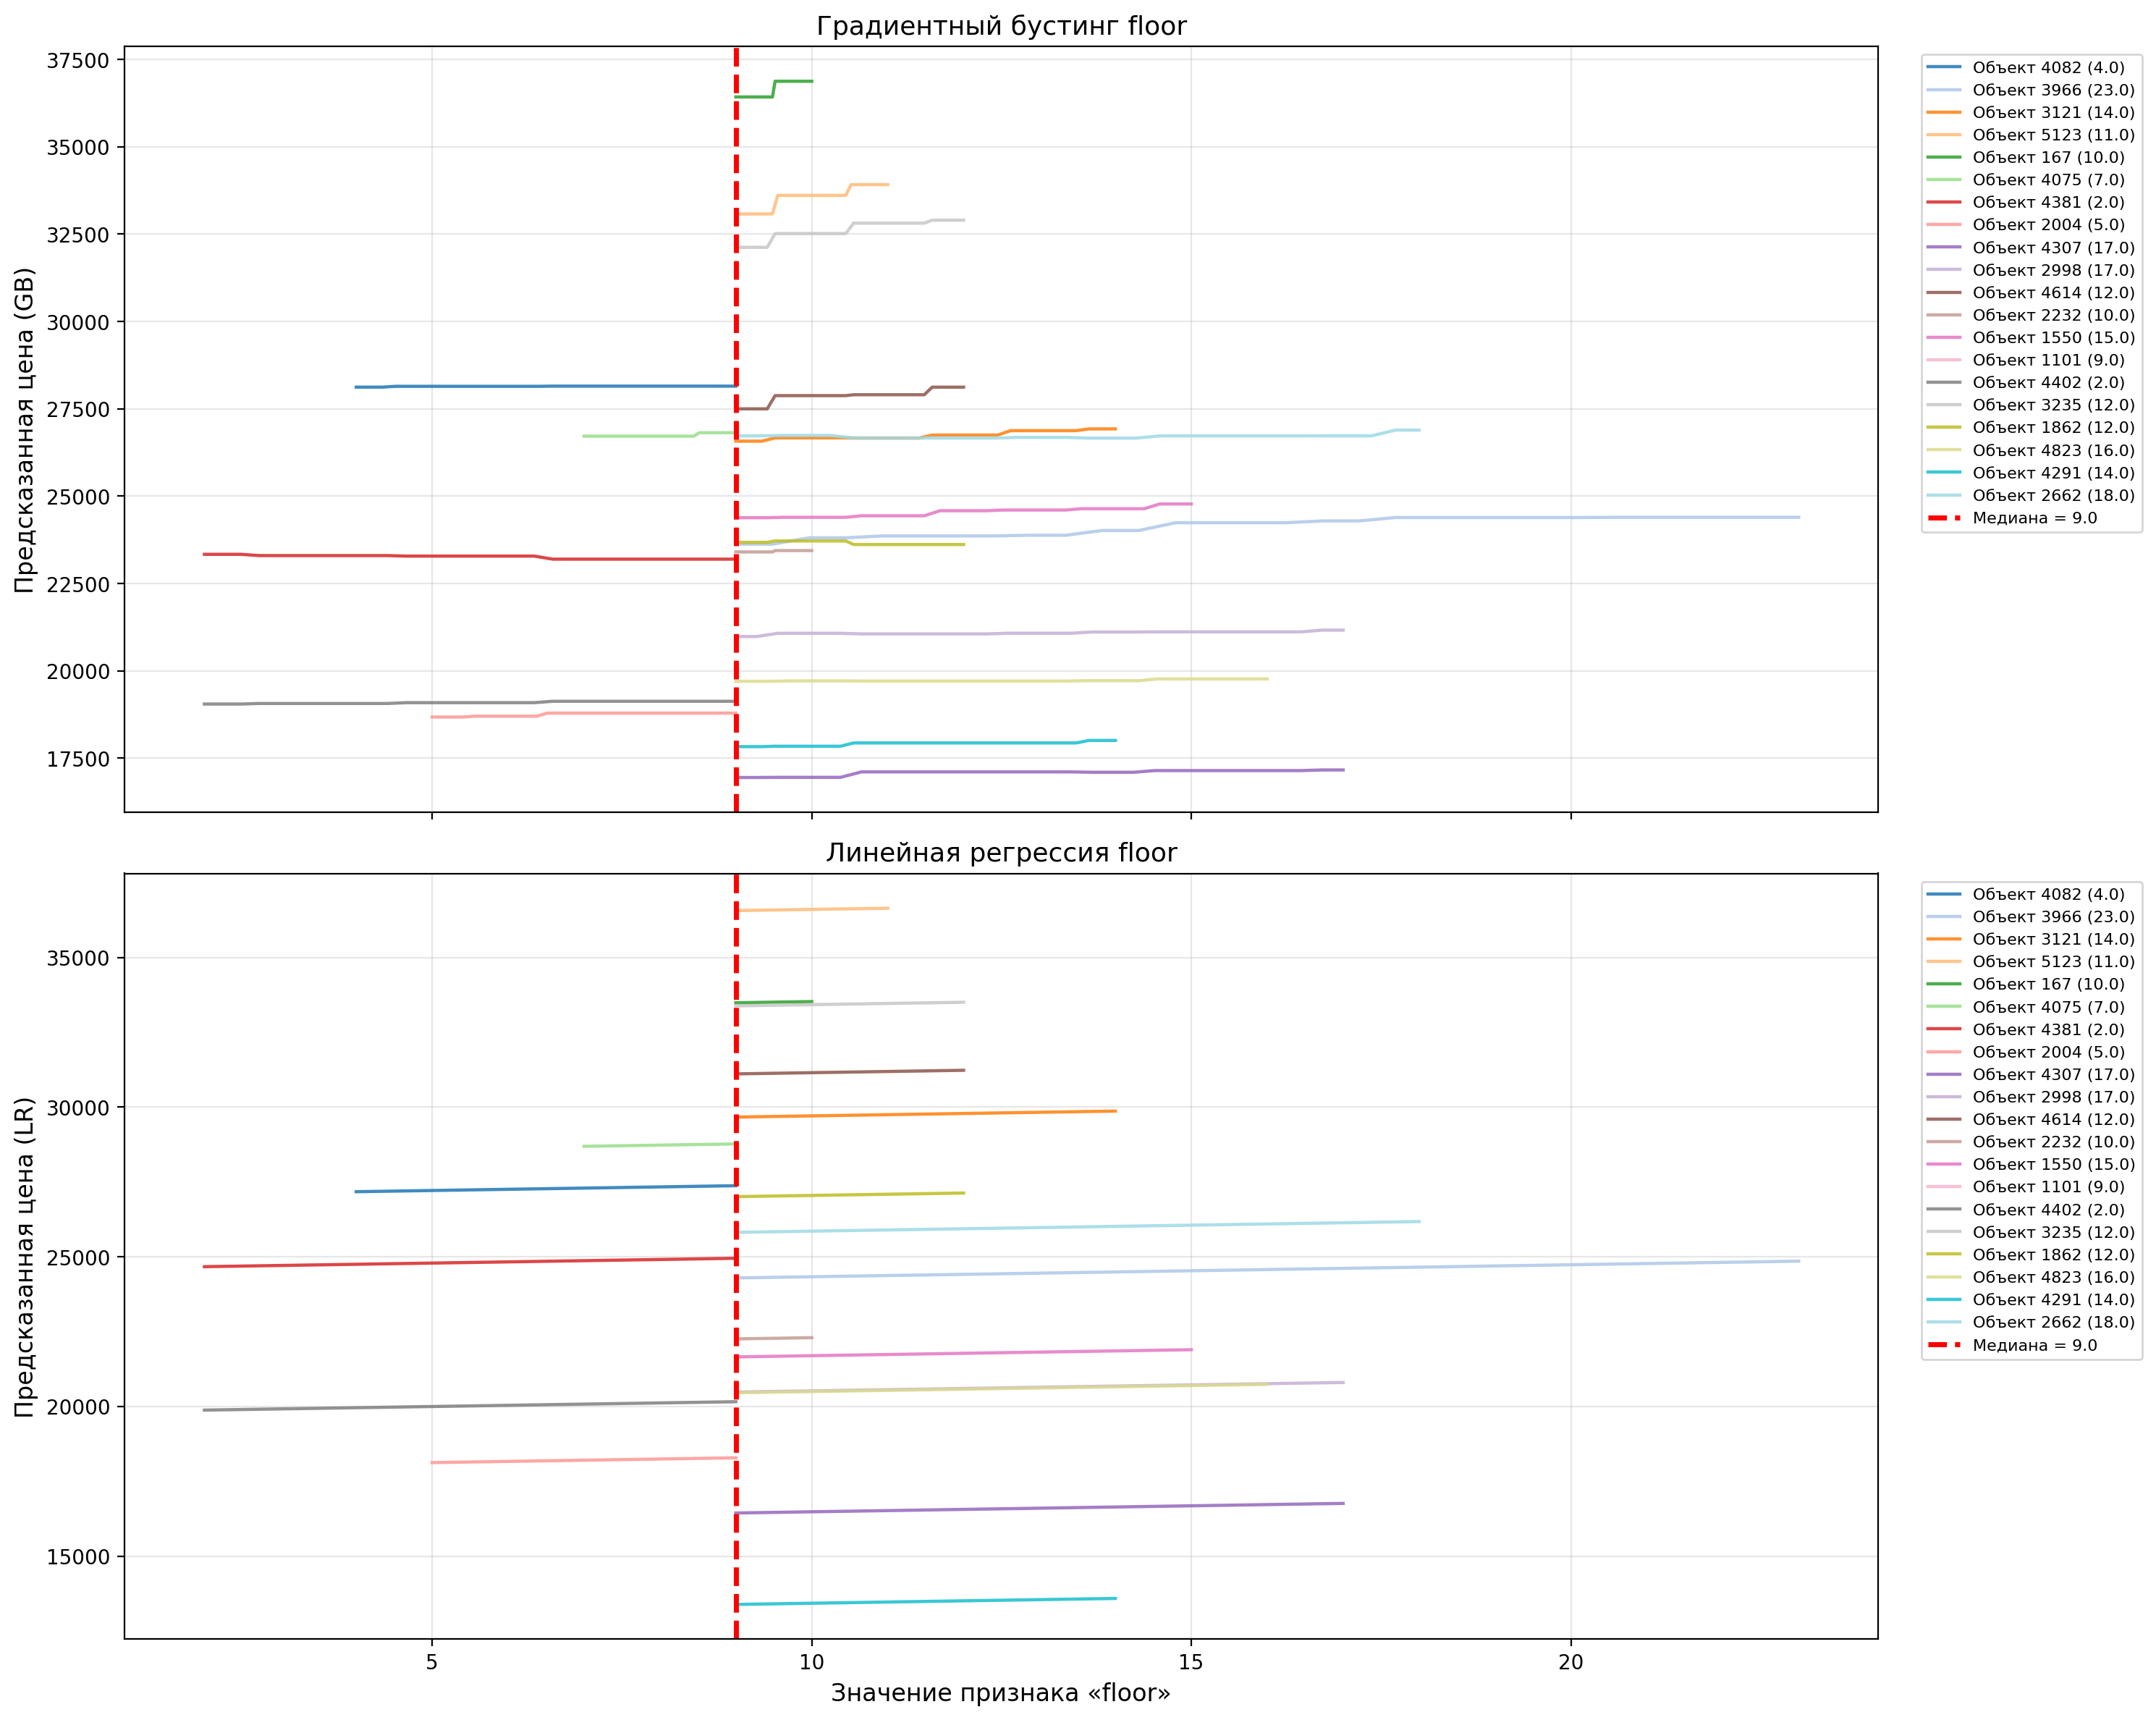

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

feature = 'floor'
n_objects = 20
n_steps = 30
baseline = X_train[feature].median()

print(f"Признак: {feature}")
print(f"Базовое значение (медиана по train): {baseline:.2f}")

gb_raw = GradientBoostingRegressor(max_depth=5, n_estimators=100, random_state=42)
gb_raw.fit(X_train, y_train)

lr_raw = LinearRegression()
lr_raw.fit(X_train, y_train)

np.random.seed(42)
selected_idx = np.random.choice(len(X_test), n_objects, replace=False)
X_selected = X_test.iloc[selected_idx].copy().reset_index(drop=True)

fig, (ax_gb, ax_lr) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

colors = plt.cm.tab20(np.linspace(0, 1, n_objects))

for i in range(n_objects):
    row = X_selected.iloc[[i]].copy()
    current_val = row[feature].iloc[0]
    interp_vals = np.linspace(current_val, baseline, n_steps)
    
    pred_gb = []
    pred_lr = []
    
    for val in interp_vals:
        row_mod = row.copy()
        row_mod[feature] = val
        pred_gb.append(gb_raw.predict(row_mod)[0])
        pred_lr.append(lr_raw.predict(row_mod)[0])
    
    ax_gb.plot(interp_vals, pred_gb, color=colors[i], linewidth=1.6, alpha=0.85, label=f'Объект {selected_idx[i]} ({current_val:.1f})')
    
    ax_lr.plot(interp_vals, pred_lr, color=colors[i], linewidth=1.6, alpha=0.85, label=f'Объект {selected_idx[i]} ({current_val:.1f})')

ax_gb.axvline(baseline, color='red', linestyle='--', linewidth=2.5, label=f'Медиана = {baseline:.1f}')
ax_lr.axvline(baseline, color='red', linestyle='--', linewidth=2.5, label=f'Медиана = {baseline:.1f}')

ax_gb.set_ylabel('Предсказанная цена (GB)', fontsize=12)
ax_lr.set_ylabel('Предсказанная цена (LR)', fontsize=12)
ax_lr.set_xlabel(f'Значение признака «{feature}»', fontsize=12)

ax_gb.set_title(f'Градиентный бустинг {feature}', fontsize=13)
ax_lr.set_title(f'Линейная регрессия {feature}', fontsize=13)

ax_gb.grid(True, alpha=0.3)
ax_lr.grid(True, alpha=0.3)

ax_gb.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax_lr.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

- В градиентном бустинге зависимость от этажа при малом числе этажей очень слабая — большинство траекторий практически горизонтальные если меньше 8 этажей. При значении этажа выше 8 заметны скачки цены в большую сторону.
- В линейной регрессии зависимость постоянно остаётся положительной и почти линейной.

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

PyALE._ALE_generic:INFO: Continuous feature detected.


Строим ALE для признака: floor


PyALE._ALE_generic:INFO: Continuous feature detected.


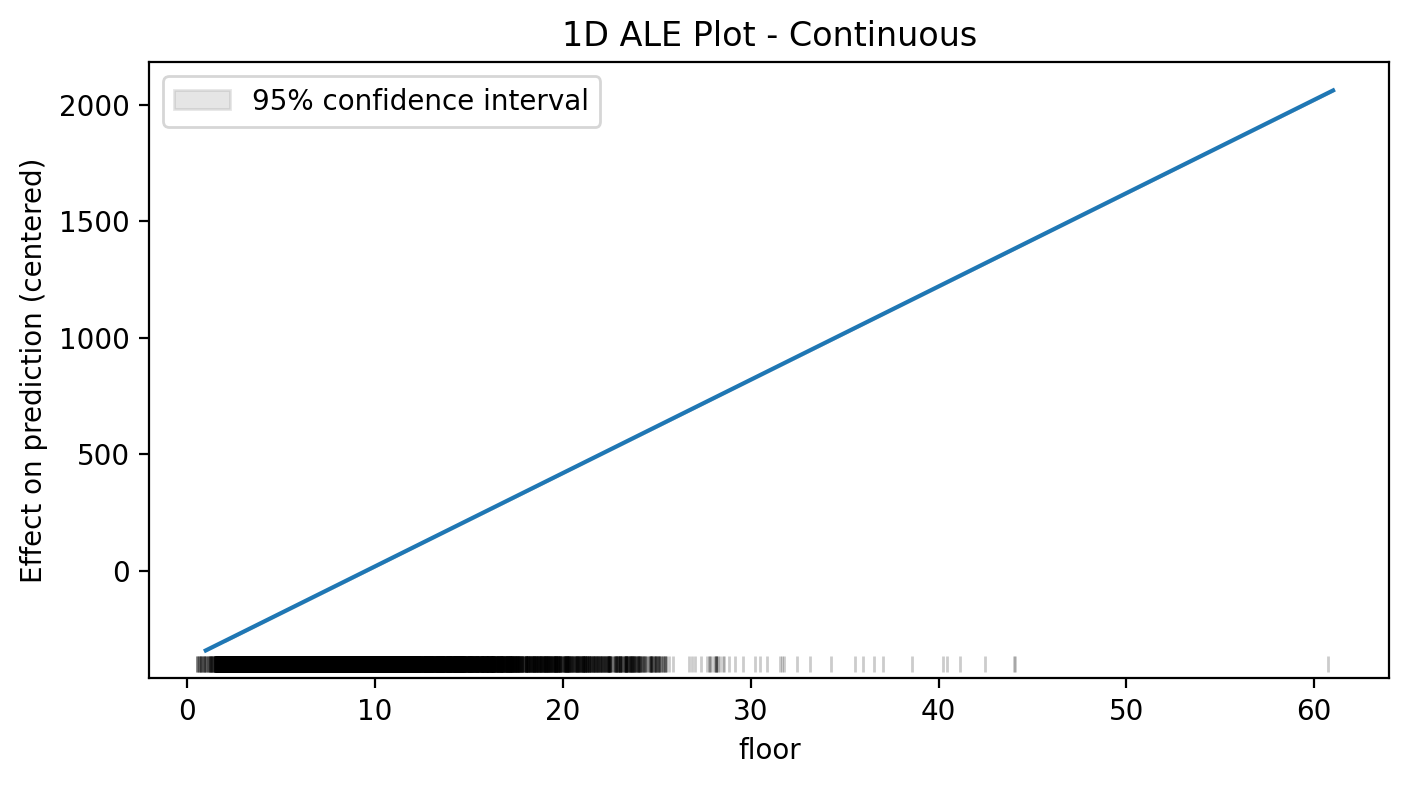

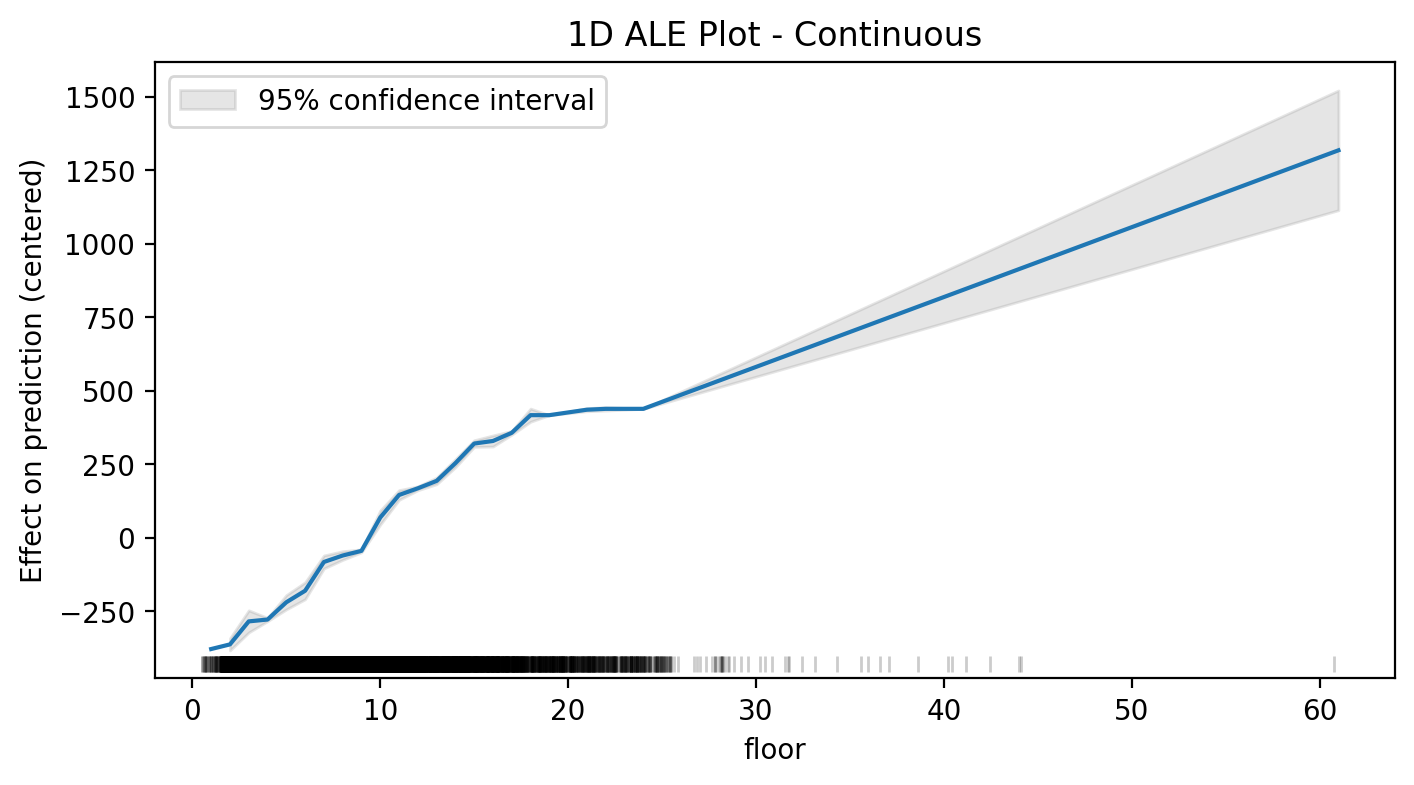

In [19]:
from PyALE import ale
import matplotlib.pyplot as plt
import numpy as np


feature = 'floor'

print(f"Строим ALE для признака: {feature}")

ale_lr = ale(
    X=X_test,
    model=lr_raw,
    feature=[feature],
    grid_size=50,
    include_CI=True,
    C=0.95,
)

ale_gb = ale(
    X=X_test,
    model=gb_raw,
    feature=[feature],
    grid_size=50,
    include_CI=True,
    C=0.95,
)

### Каковы получились доверительные интервалы?
- LR: очень узкие (даже невидимые)
- GB: заметно широкие, особенно на краях распределения этажей

### Почему они различны для моделей?
- Потому что:
    - Линейная регрессия — детерминированная и глобально линейная. Эффект от изменения floor на 1 одинаков для всех квартир -очень маленькая вариация, что дает узкие CI.
    - Градиентный бустинг — сложная нелинейная модель с множеством взаимодействий. Один и тот же сдвиг floor в разных районах/типах домов даёт сильно разный прирост цены. Плюс в редких зонах (очень низкие или очень высокие этажи) мало данных ведёт к высокой неопределённости, что даёт широкие доверительные интервалы.

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?

In [20]:
from sklearn.inspection import permutation_importance
import pandas as pd

n_repeats_values = [5, 10, 20, 30, 50, 100]

for n in n_repeats_values:
    print(f"\nn_repeats = {n}")
    
    # LR
    perm_lr = permutation_importance(
        lr_raw,
        X_test_raw, y_test,
        n_repeats=n,
        random_state=42,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1
    )
    
    imp_lr = pd.DataFrame({
        'importance_mean': perm_lr.importances_mean,
        'importance_std':  perm_lr.importances_std,
        'feature':         X_test.columns
    }).sort_values('importance_mean', ascending=False).head(5)
    
    print("   LR_raw: топ-5")
    print(imp_lr[['importance_mean', 'importance_std', 'feature']].to_string(index=False))
    
    # GB
    perm_gb = permutation_importance(
        gb_raw,
        X_test_raw, y_test,
        n_repeats=n,
        random_state=42,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1
    )
    
    imp_gb = pd.DataFrame({
        'importance_mean': perm_gb.importances_mean,
        'importance_std':  perm_gb.importances_std,
        'feature':         X_test.columns
    }).sort_values('importance_mean', ascending=False).head(5)
    
    print("   GB_raw: топ-5")
    print(imp_gb[['importance_mean', 'importance_std', 'feature']].to_string(index=False))


n_repeats = 5
   LR_raw: топ-5
 importance_mean  importance_std                                feature
        0.114509        0.000785 location_public_transport_platform_cnt
        0.080318        0.001063                  location_pop_shop_cnt
        0.069966        0.001372               location_std_levels_mean
        0.067037        0.000668                              class_cat
        0.066373        0.000876  location_amenity_bank_w_mean_distance
   GB_raw: топ-5
 importance_mean  importance_std                                     feature
        0.150218        0.002409                                   class_cat
        0.049153        0.000897                    location_logs_count_mean
        0.023076        0.000306 location_public_transport_stop_position_cnt
        0.015971        0.000272                                district_cat
        0.013084        0.000173               location_town_w_mean_distance

n_repeats = 10
   LR_raw: топ-5
 importance_mean  import

### LR:
- Топ-5 признаков полностью стабильны при всех значениях n_repeats от 5 до 100.
- Порядок и значения importance_mean почти не меняются.
- Максимальное отклонение между n=5 и n=100 — менее 0.001.
Вывод: даже при 5 перестановках средняя важность уже точно оценена.

### GB:
- Топ-5 тоже абсолютно стабильны.
- class_cat всегда доминирует (~0.1501–0.1507), второе место — location_logs_count_mean (~0.0481–0.0492).
- Отклонения значений — менее 0.001.
- Бустинг даёт более контрастную важность (class_cat в 3-4 раза важнее второго признака).

### Как меняется importance_std (неопределённость оценки) для топ 1 признака:

| n_repeats | LR_raw (std)          | GB_raw (std)          |
|-----------|-----------------------|-----------------------|
| 5         | 0.000785              | 0.002409              |
| 10        | 0.000842              | 0.002400              |
| 20        | 0.001352              | 0.001944              |
| 30        | 0.001323              | 0.002152              |
| 50        | 0.001389              | 0.002288              |
| 100       | 0.001468              | 0.002199              |

### Выводы:

- При увеличении n_repeats importance_mean не меняется (уже стабильно с n=5).
- importance_std сначала немного растёт (лучше оценивается реальная вариабельность), затем стабилизируется.
- У линейной регрессии std в 2–3 раза меньше, чем у бустинга — это ожидаемо (линейная модель менее чувствительна к перестановкам).

Таким образом, permutation importance в этой задаче очень устойчива — топ-признаки и их ранжирование не безумно зависят от количества перестановок.

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$) медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

Baseline MAPE: 4.0303%



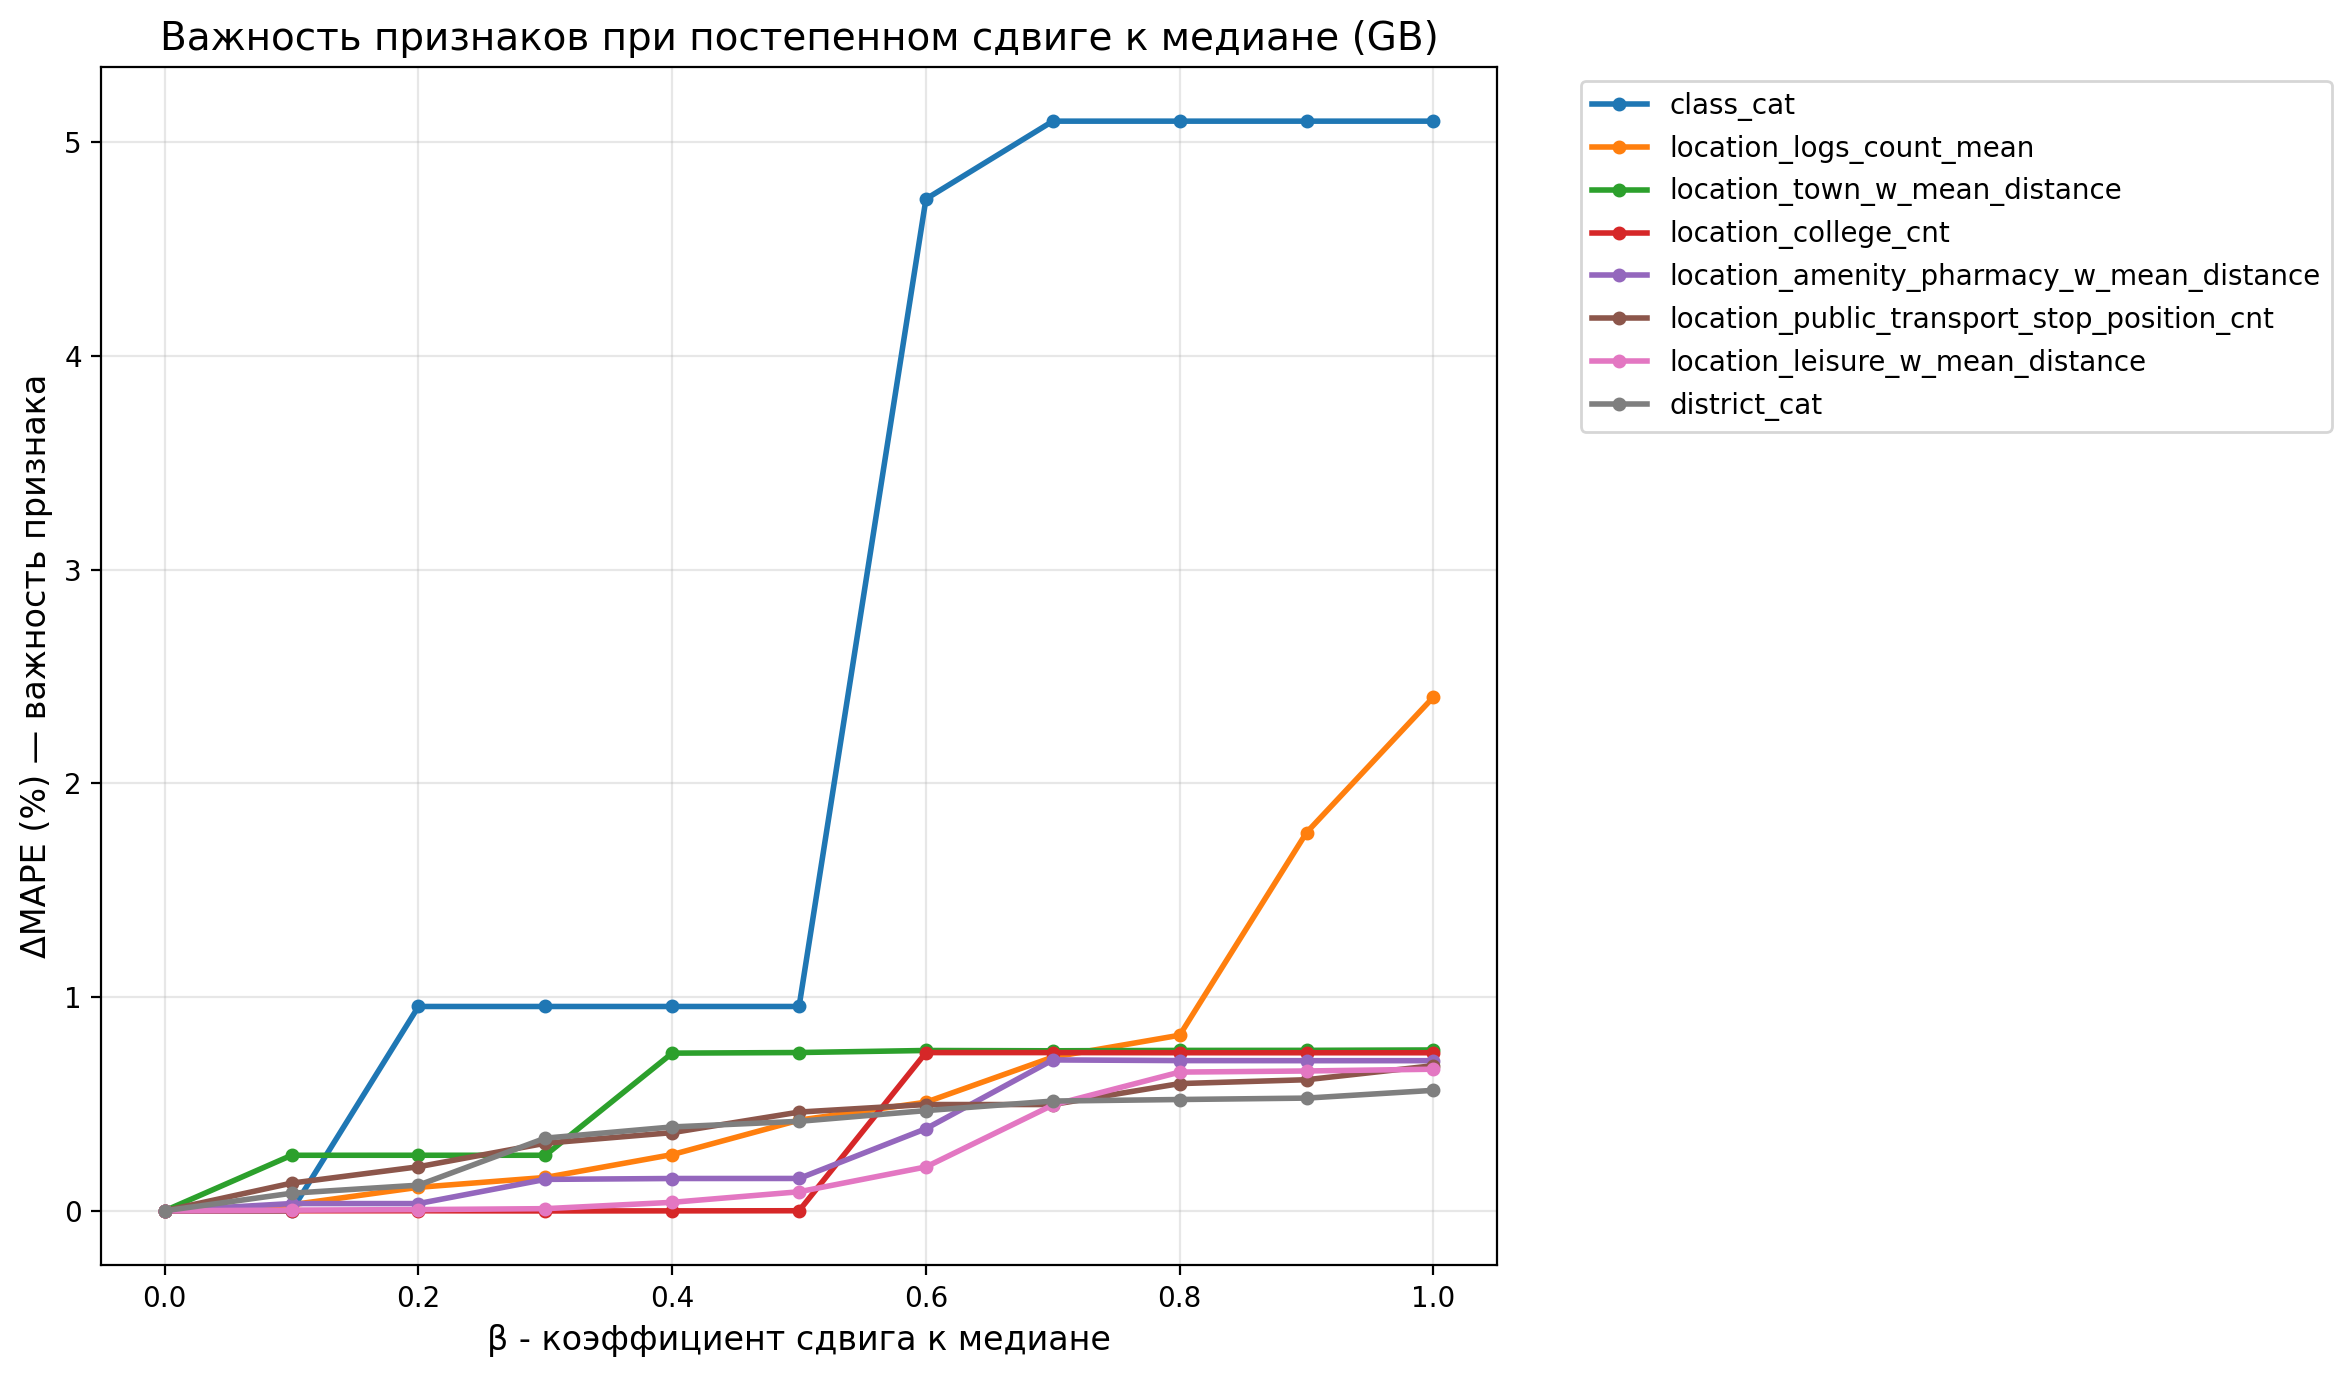

Топ-10 признаков по важности (при β=1.0) - при полном сдвиге:
class_cat                                      5.0986
location_logs_count_mean                       2.4036
location_town_w_mean_distance                  0.7524
location_college_cnt                           0.7402
location_amenity_pharmacy_w_mean_distance      0.7059
location_public_transport_stop_position_cnt    0.6790
location_leisure_w_mean_distance               0.6624
district_cat                                   0.5636
square                                         0.5255
location_shop_product_w_mean_distance          0.4775
dtype: float64


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

model = gb_raw
X_train = X_train_raw
X_test  = X_test_raw
y_true  = y_test

numeric_features = [col for col in X_train.columns if X_train[col].dtype in ['int64', 'float64'] and not col.startswith('region_')]

medians = X_train[numeric_features].median()

baseline_pred = model.predict(X_test)
baseline_mape = mean_absolute_percentage_error(y_true, baseline_pred) * 100
print(f"Baseline MAPE: {baseline_mape:.4f}%\n")

betas = np.arange(0.0, 1.01, 0.1)
importance_dict = {feat: [] for feat in numeric_features}

for beta in betas:
    for feat in numeric_features:
        X_pert = X_test.copy()
        X_pert[feat] = (1 - beta) * X_pert[feat] + beta * medians[feat]
        
        pred_pert = model.predict(X_pert)
        mape_pert = mean_absolute_percentage_error(y_true, pred_pert) * 100
        delta_mape = mape_pert - baseline_mape
        
        importance_dict[feat].append(delta_mape)

imp_df = pd.DataFrame(importance_dict, index=betas)

top_features = imp_df.max().sort_values(ascending=False).head(8).index.tolist()

plt.figure(figsize=(12, 7))
for feat in top_features:
    plt.plot(imp_df.index, imp_df[feat], label=feat, linewidth=2, marker='o', markersize=4)

plt.xlabel('β - коэффициент сдвига к медиане', fontsize=12)
plt.ylabel('ΔMAPE (%) — важность признака', fontsize=12)
plt.title('Важность признаков при постепенном сдвиге к медиане (GB)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

max_imp = imp_df.max().sort_values(ascending=False).head(10)
print("Топ-10 признаков по важности (при β=1.0) - при полном сдвиге:")
print(max_imp.round(4))

### Как меняются важности при разных $\beta$?

- При $\beta = 0$ — $\Delta\text{MAPE} = 0$ (признак не изменён).
- По мере роста $\beta$ важность монотонно увеличивается у всех признаков.
- У самых важных признаков (особенно `class_cat`) наблюдается резкий взлёт после $\beta \approx 0.5$ с выходом на максимум уже при $\beta = 0.7$.
- У остальных признаков рост более постепенный.
- Максимальная важность достигается при $\beta = 1.0$ (полная замена признака на медиану).

### Сравнение с Permutation Importance

| Метод                          | 1-е место                  | 2-е место                        | Абсолютные значения ΔMAPE | Характер возмущения                     |
|--------------------------------|----------------------------|----------------------------------|---------------------------|-----------------------------------------|
| Permutation Importance         | class_cat (~0.150)         | location_logs_count_mean (~0.048)| маленькие                 | Полное случайное перемешивание          |
| Сдвиг к медиане ($\beta=1.0$)  | class_cat (5.10)           | location_logs_count_mean (2.40)  | в 30–40 раз больше        | Постепенное усреднение до типичного значения |

### Есть ли различия между методами?  
Да, но они не принципиальные:
- Порядок топ признаков полностью совпадает.
- Permutation Importance даёт более контрастные, но меньшие по абсолюту значения.
- Метод сдвига к медиане показывает реальное влияние отклонения признака от типичного значения.

### Причины различий:
- Permutation полностью разрушает связь признака с целевой переменной и ломает корреляции с другими признаками.
- Сдвиг к медиане сохраняет корреляционную структуру данных, меняя только центр распределения.
- Поэтому второй метод даёт более мягкую и интерпретируемую важность.

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME.
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 

In [49]:
from lime.lime_tabular import LimeTabularExplainer


explainer = LimeTabularExplainer(
    training_data=X_train_raw.values,
    feature_names=list(X_train_raw.columns),
    mode='regression',
    discretize_continuous=True,
    random_state=42,
    kernel_width=None
)

example_indices = [0, 50, 100, 500, 1000]

print("LIME объяснения для GradientBoostingRegressor (gb_raw)")

for idx in example_indices:
    instance = X_test_raw.iloc[idx].values
    true_price = y_test.iloc[idx]
    pred_price = gb_raw.predict([instance])[0]
    
    print()
    print(f"Объект №{idx} | Истинная цена: {true_price:.1f} | Предсказанная: {pred_price:.1f}")
    
    exp = explainer.explain_instance(
        data_row=instance,
        predict_fn=gb_raw.predict,
        num_features=10,
        num_samples=5000,
        distance_metric='euclidean'
    )
    
    print("Топ-10 вкладов LIME:")
    for feature, weight in exp.as_list():
        print(f"   {feature:45} → {weight:+.4f}")

LIME объяснения для GradientBoostingRegressor (gb_raw)

Объект №0 | Истинная цена: 33456.0 | Предсказанная: 32686.0
Топ-10 вкладов LIME:
   class_cat <= 27353.00                         → +12135.8625
   location_public_transport_stop_position_cnt > 34.00 → +1842.9851
   location_town_w_mean_distance <= 0.88         → -1358.8145
   22.57 < location_logs_count_mean <= 23.74     → +948.7441
   2012.00 < year <= 2013.00                     → +802.3555
   1.00 < location_railway_station_cnt <= 2.00   → -758.5845
   location_car_rental_cnt <= 0.00               → -734.1864
   48.00 < district_cat <= 71.00                 → -717.7657
   8977.00 < interior_cat <= 49786.00            → +666.4627
   27728.00 < stage_cat <= 70661.00              → +634.1797

Объект №50 | Истинная цена: 17602.4 | Предсказанная: 17075.5
Топ-10 вкладов LIME:
   27353.00 < class_cat <= 97865.00              → -12003.9467
   location_logs_count_mean <= 21.52             → -1534.0010
   location_motel_cnt <= 0.00      

### Функция для запуска LIME с параметрами

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

def run_lime_experiment(model, X_train, X_test, feature_names, idx=0, num_samples=5000, feature_selection='lasso_path', kernel_width=None, random_state=42):

    explainer = LimeTabularExplainer(
        X_train,
        feature_names=feature_names,
        mode='regression',
        random_state=random_state,
        kernel_width=kernel_width,
        feature_selection=feature_selection
    )

    exp = explainer.explain_instance(
        X_test[idx],
        model.predict,
        num_features=10,
        num_samples=num_samples
    )

    return exp.as_list()

### Проверка устойчивости по числу сэмплов

In [53]:
sample_sizes = [500, 2000, 5000, 10000]

results_samples = {}

feature_names = X_train.columns.tolist()

for n in sample_sizes:
    res = run_lime_experiment(
        gb_raw, X_train.values, X_test.values, feature_names,
        idx=0,
        num_samples=n
    )
    results_samples[n] = res

for n, res in results_samples.items():
    print(f"\nnum_samples = {n}")
    for f, w in res[:5]:
        print(f"{f:40s} {w:.4f}")


num_samples = 500
class_cat <= 27353.00                    11955.1918
369.00 < location_buildings_cnt <= 538.00 -1763.6750
1.00 < location_college_cnt <= 2.00      1741.3755
location_parking_cnt > 106.00            1636.8470
6.00 < location_marketplace_cnt <= 11.00 1534.3533

num_samples = 2000
class_cat <= 27353.00                    11270.3433
location_public_transport_stop_position_cnt > 34.00 1584.3614
22.57 < location_logs_count_mean <= 23.74 1168.3104
27728.00 < stage_cat <= 70661.00         883.8256
1.00 < location_railway_station_cnt <= 2.00 857.7335

num_samples = 5000
class_cat <= 27353.00                    12134.2354
location_public_transport_stop_position_cnt > 34.00 1828.2959
location_town_w_mean_distance <= 0.88    -1342.8505
22.57 < location_logs_count_mean <= 23.74 946.8523
2012.00 < year <= 2013.00                788.8646

num_samples = 10000
class_cat <= 27353.00                    12078.7724
location_public_transport_stop_position_cnt > 34.00 1767.3819
22.57 < loca

### Проверка устойчивости к случайности

In [50]:
runs = 3
stability_results = []

for seed in range(runs):
    res = run_lime_experiment(
        gb_raw, X_train.values, X_test.values, feature_names,
        idx=idx,
        num_samples=5000,
        random_state=seed
    )
    stability_results.append(res)

for i, res in enumerate(stability_results):
    print(f"\nRun {i}")
    for f, w in res[:5]:
        print(f"{f:40s} {w:.4f}")


Run 0
27353.00 < class_cat <= 97865.00         -12204.7210
location_logs_count_mean <= 21.52        -1912.6000
location_town_w_mean_distance <= 0.88    -1255.2305
location_public_transport_stop_position_cnt <= 9.00 -802.1925
location_college_cnt <= 0.00             -757.7430

Run 1
27353.00 < class_cat <= 97865.00         -11368.8578
location_logs_count_mean <= 21.52        -1811.9769
location_town_w_mean_distance <= 0.88    -1142.7705
location_public_transport_stop_position_cnt <= 9.00 -1004.7441
region_Пригород <= 0.00                  686.7813

Run 2
27353.00 < class_cat <= 97865.00         -11969.7064
location_logs_count_mean <= 21.52        -1828.2628
location_town_w_mean_distance <= 0.88    -1041.7760
27728.00 < stage_cat <= 70661.00         941.9818
floor > 13.00                            916.8933


### Влияние ширины ядра

In [54]:
kernel_widths = [0.25, 1, 3]

results_kernel = {}

for kw in kernel_widths:
    res = run_lime_experiment(
        gb_raw, X_train.values, X_test.values, feature_names,
        idx=idx,
        kernel_width=kw
    )
    results_kernel[kw] = res

for kw, res in results_kernel.items():
    print(f"\nkernel_width = {kw}")
    for f, w in res[:5]:
        print(f"{f:40s} {w:.4f}")


kernel_width = 0.25
location_shop_alco_w_mean_distance <= 0.71 -0.0000
0.71 < location_amenity_restaurant_w_mean_distance <= 0.89 -0.0000
0.00 < interior_cat <= 8977.00           -0.0000
location_residential_w_mean_distance <= 0.72 -0.0000
location_school_w_mean_distance <= 0.81  -0.0000

kernel_width = 1
0.00 < interior_cat <= 8977.00           -0.0044
25.00 < location_max_levels_max <= 32.00 -0.0038
location_logs_count_mean <= 21.52        -0.0035
0.71 < location_amenity_restaurant_w_mean_distance <= 0.89 -0.0035
274.00 < hc_name_cat <= 341.00           -0.0034

kernel_width = 3
27353.00 < class_cat <= 97865.00         -11983.2313
location_logs_count_mean <= 21.52        -1869.2052
location_town_w_mean_distance <= 0.88    -1203.3949
location_public_transport_stop_position_cnt <= 9.00 -1191.4629
274.00 < hc_name_cat <= 341.00           -1148.4803


### 1. Общие наблюдения по интерпретациям (5 объектов):

LIME стабильно выделяет **class_cat** как доминирующий признак во всех пяти примерах:

- Когда `class_cat ≤ 27353` — вклад +11–12 тыс. (положительный).
- Когда `27353 < class_cat ≤ 97865` — вклад –11.9–12.5 тыс. (отрицательный).

Второстепенные признаки меняются в зависимости от объекта:
- `location_logs_count_mean`
- `location_public_transport_stop_position_cnt`
- `location_town_w_mean_distance`
- `location_motel_cnt`
- `district_cat`
- `stage_cat`

Вклады этих признаков обычно в диапазоне +-700 до +-2000, т.е. на порядок меньше, чем у `class_cat`.

### 2. Устойчивость к количеству сгенерированных точек (num_samples):

| num_samples | Топ-1 признак          | Вклад class_cat | Стабильность топ-5 |
|-------------|------------------------|-----------------|--------------------|
| 500         | class_cat              | +11 955         | низкая             |
| 2000        | class_cat              | +11 270         | средняя            |
| 5000        | class_cat              | +12 134         | высокая            |
| 10000       | class_cat              | +12 079         | очень высокая      |

#### Вывод:  
При 5000+ сэмплах объяснения стабилизируются. При 500 сэмплах появляются случайные признаки — объяснение ненадёжно.  

### 3. Устойчивость к случайности (разные random_state)

Три запуска при `num_samples=5000`:
- Топ-1 всегда `class_cat` (вклад от –11 368 до –12 204).
- Вторые-третьи места иногда меняются местами, но остаются в топ-5.

#### Вывод: LIME умеренно устойчив к случайности. Для важных выводов стоит усреднять 3–5 запусков.

### 4. Влияние ширины ядра (kernel_width)

| kernel_width | Поведение весов                              | Качество объяснения |
|--------------|----------------------------------------------|---------------------|
| 0.25         | почти все веса ≈ 0                           | плохое              |
| 1.0          | веса очень маленькие                         | слабое              |
| 3.0          | полноценные веса (–12k для class_cat)        | отличное            |

### 5. Итог:

1. Использовать **num_samples ≥ 5000**.
2. Ставить **kernel_width ≥ 3** (или `None`).
3. Для важных объектов запускать **3–5 раз** и усреднять вклады.
4. `class_cat` — самый надёжный и сильный признак (всегда в топ-1 с огромным отрывом).

## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 

Объект - 5
Истинная цена: 17718.07

GradientBoostingRegressor
Предсказание: 18349.71
Base value:    24579.34
Base + SHAP:   18349.71


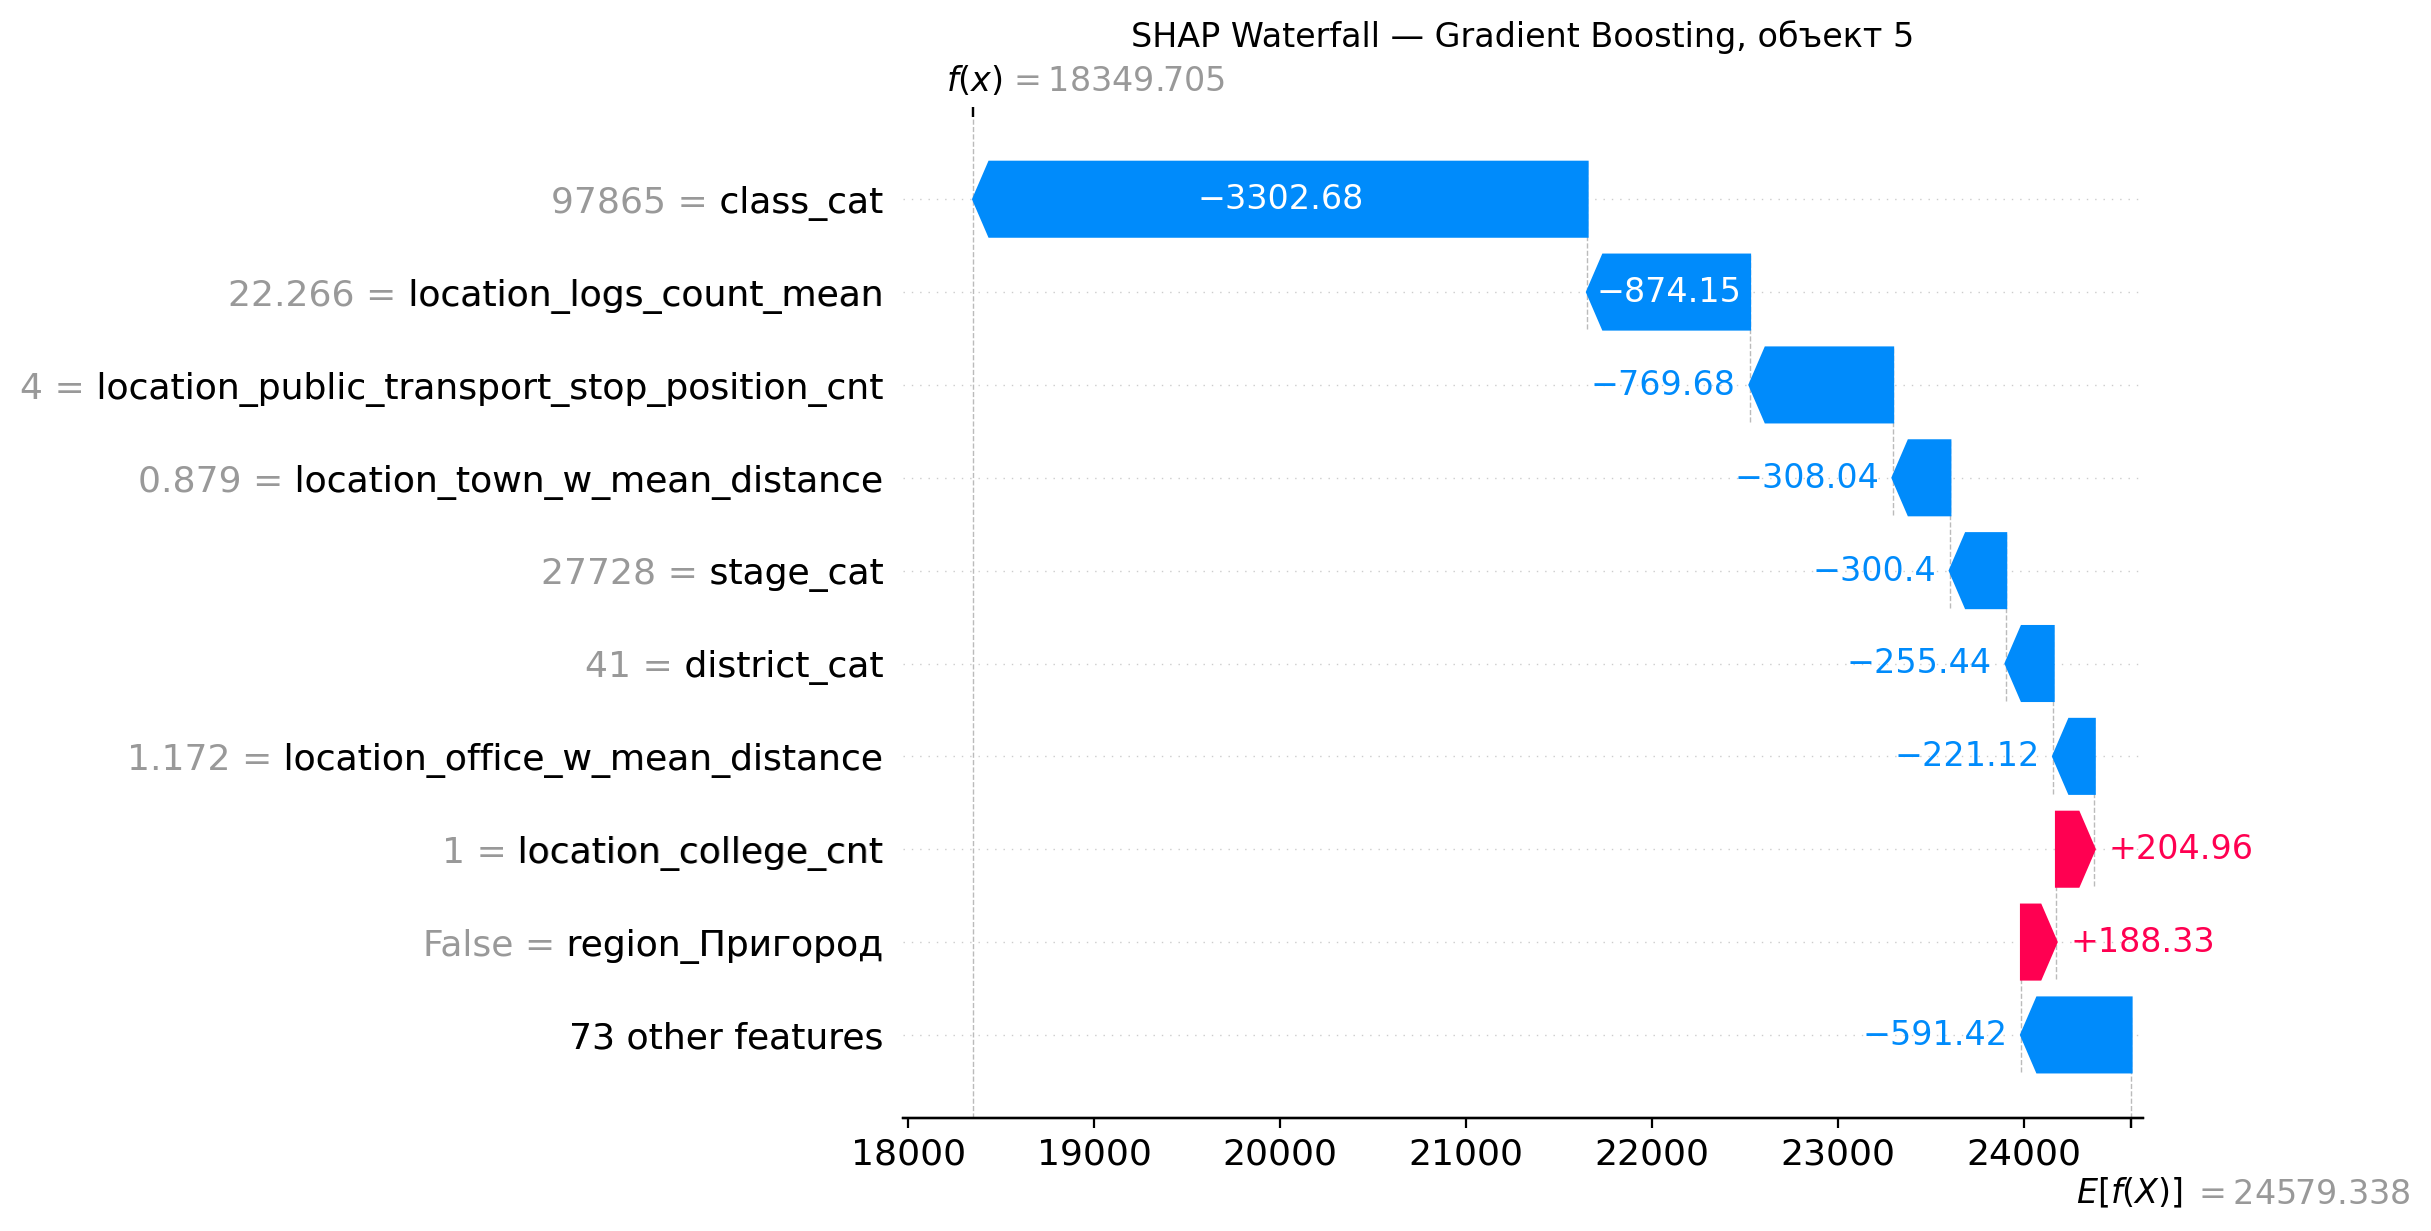


LinearRegression
Предсказание: 17969.40
Base value:    24569.54
Base + SHAP:   17969.40


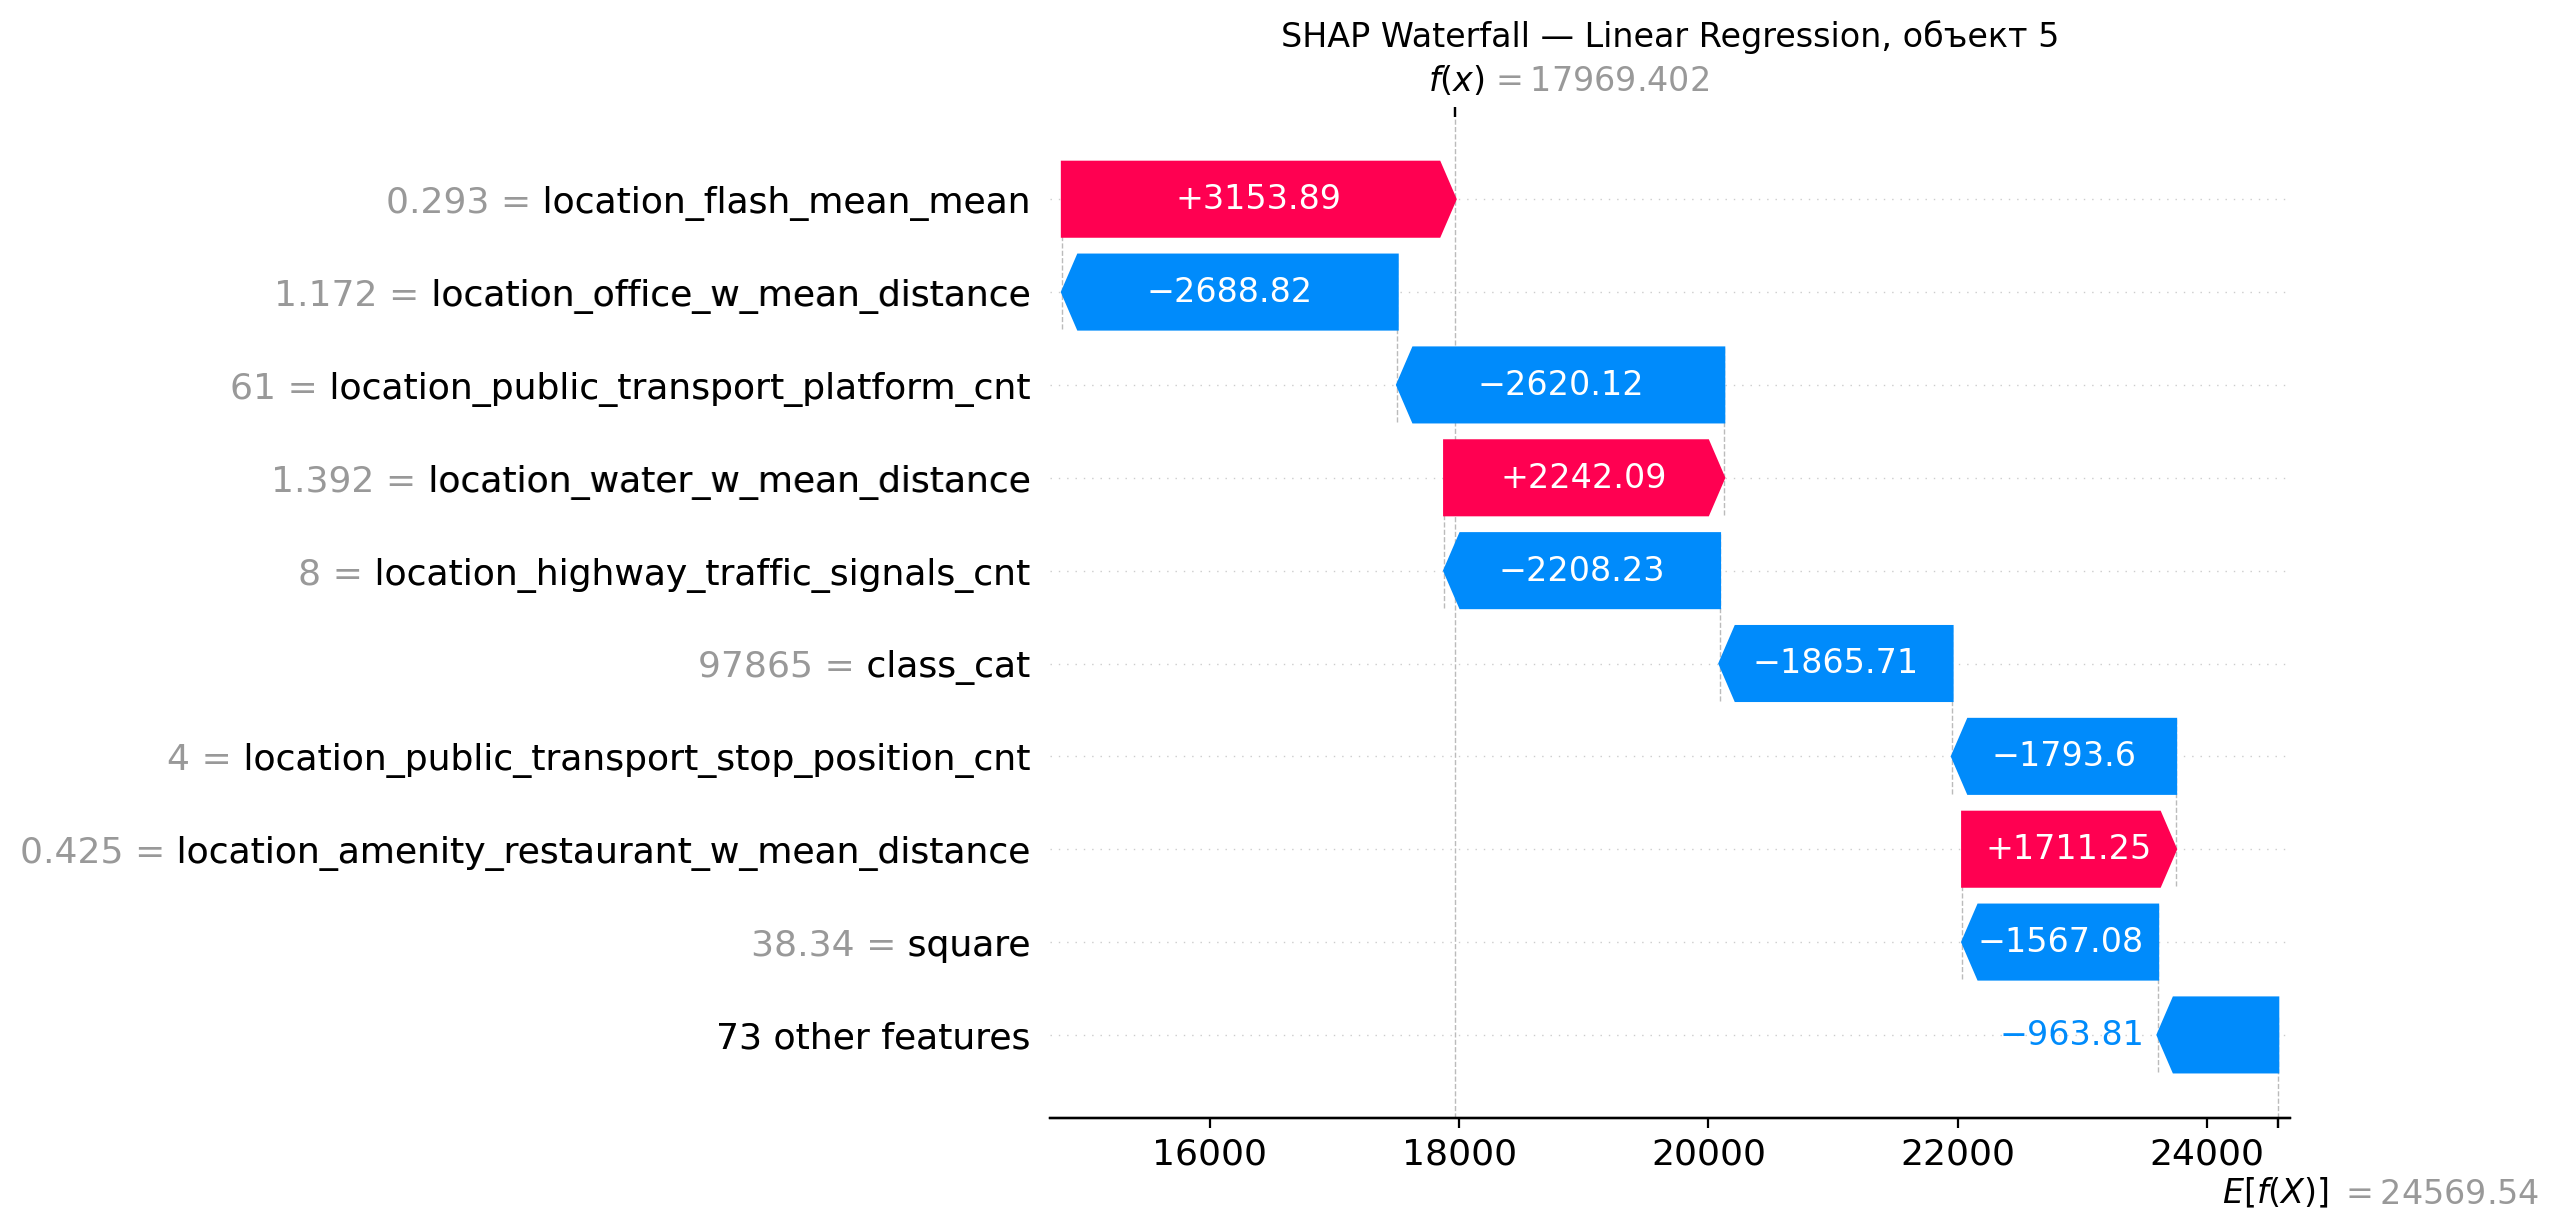

In [77]:
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

idx = 5

gb_model = GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=100)
gb_model.fit(X_train_raw, y_train)

lr_model = LinearRegression()
lr_model.fit(X_train_raw, y_train)

print(f"Объект - {idx}")
print(f"Истинная цена: {y_test.iloc[idx]:.2f}\n")

explainer_gb = shap.TreeExplainer(gb_model)
shap_values_gb = explainer_gb(X_test_raw)

gb_pred = gb_model.predict(X_test_raw.iloc[[idx]])[0]
gb_base = shap_values_gb.base_values[idx]
gb_sum = shap_values_gb.values[idx].sum()

print("GradientBoostingRegressor")
print(f"Предсказание: {gb_pred:.2f}")
print(f"Base value:    {gb_base:.2f}")
print(f"Base + SHAP:   {gb_base + gb_sum:.2f}")

plt.figure(figsize=(10, 6))
plt.title(f"SHAP Waterfall — Gradient Boosting, объект {idx}")
shap.plots.waterfall(shap_values_gb[idx], max_display=10)
plt.show()

explainer_lr = shap.LinearExplainer(lr_model, X_train_raw)
shap_values_lr = explainer_lr(X_test_raw)

lr_pred = lr_model.predict(X_test_raw.iloc[[idx]])[0]
lr_base = shap_values_lr.base_values[idx]
lr_sum = shap_values_lr.values[idx].sum()

print("\nLinearRegression")
print(f"Предсказание: {lr_pred:.2f}")
print(f"Base value:    {lr_base:.2f}")
print(f"Base + SHAP:   {lr_base + lr_sum:.2f}")

plt.figure(figsize=(10, 6))
plt.title(f"SHAP Waterfall — Linear Regression, объект {idx}")
shap.plots.waterfall(shap_values_lr[idx], max_display=10)
plt.show()

## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 

In [78]:
import shap
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor

idx = 5
cat_feature = "class_cat"

print(f"Объект - {idx}")
print(f"Истинная цена: {y_test.iloc[idx]:.2f}\n")

gb_num = GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=100)
gb_num.fit(X_train_raw, y_train)

explainer_num = shap.TreeExplainer(gb_num)
shap_values_num = explainer_num(X_test_raw)

cat_pos = X_test_raw.columns.get_loc(cat_feature)
cat_shap_num = shap_values_num.values[idx, cat_pos]

pred_num = gb_num.predict(X_test_raw.iloc[[idx]])[0]
base_num = shap_values_num.base_values[idx]

print("1) Исходный признак class_cat (без one-hot)")
print(f"Предсказание:          {pred_num:.2f}")
print(f"Base value:            {base_num:.2f}")
print(f"SHAP для class_cat:     {cat_shap_num:.2f}")
print(f"Base + sum(SHAP):       {base_num + shap_values_num.values[idx].sum():.2f}")

X_train_oh = pd.get_dummies(
    X_train_raw,
    columns=[cat_feature],
    prefix=cat_feature,
    drop_first=True
)

X_test_oh = pd.get_dummies(
    X_test_raw,
    columns=[cat_feature],
    prefix=cat_feature,
    drop_first=True
)

X_test_oh = X_test_oh.reindex(columns=X_train_oh.columns, fill_value=0)

gb_oh = GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=100)
gb_oh.fit(X_train_oh, y_train)

explainer_oh = shap.TreeExplainer(gb_oh)
shap_values_oh = explainer_oh(X_test_oh)

dummy_cols = [c for c in X_test_oh.columns if c.startswith(f"{cat_feature}_")]
dummy_positions = [X_test_oh.columns.get_loc(c) for c in dummy_cols]
dummy_shaps = shap_values_oh.values[idx, dummy_positions]

pred_oh = gb_oh.predict(X_test_oh.iloc[[idx]])[0]
base_oh = shap_values_oh.base_values[idx]
sum_dummy = dummy_shaps.sum()

print("2) One-hot представление")
print(f"Предсказание:          {pred_oh:.2f}")
print(f"Base value:            {base_oh:.2f}")
print(f"Сумма SHAP по dummy:   {sum_dummy:.2f}")
print(f"Base + sum(dummy):     {base_oh + shap_values_oh.values[idx].sum():.2f}")

print("Вклады отдельных dummy-столбцов:")
for col, val in zip(dummy_cols, dummy_shaps):
    print(f"  {col:30s} -> {val:+.4f}")

Объект - 5
Истинная цена: 17718.07

1) Исходный признак class_cat (без one-hot)
Предсказание:          18349.71
Base value:            24579.34
SHAP для class_cat:     -3302.68
Base + sum(SHAP):       18349.71
2) One-hot представление
Предсказание:          18398.10
Base value:            24579.34
Сумма SHAP по dummy:   -3311.01
Base + sum(dummy):     18398.10
Вклады отдельных dummy-столбцов:
  class_cat_27353                -> +3633.5813
  class_cat_97865                -> -6944.5877


### В этом задании с помощью SHAP мы разобрали, из чего складывается предсказание модели для одного конкретного объекта.

#### SHAP раскладывает прогноз на две части:
- base value — это среднее предсказание модели по данным;
- вклады признаков — насколько каждый признак увеличивает или уменьшает это значение.

#### В модели GradientBoostingRegressor:

- базовое значение равно примерно 24579;
- итоговое предсказание — 18349;
- значит, суммарный вклад признаков сильно уменьшил прогноз.

#### В модели LinearRegression:

- итоговый прогноз (17969) тоже меньше базового;
- это значит, что для выбранного объекта большинство значимых признаков “тянут цену вниз”.

#### Важно, что в обеих моделях выполняется равенство:

- base value + сумма SHAP = предсказание

Это подтверждает, что SHAP рассчитан корректно и интерпретация работает правильно.

#### Также по графикам видно:

- какие признаки сильнее всего влияют на результат;
- какие увеличивают цену (положительный вклад);
- какие уменьшают (отрицательный вклад).

### Задание 7.1. Категориальный признак и one-hot

Здесь мы посмотрели, как меняется вклад категориального признака после one-hot-кодировки.
Изначально признак class_cat был один, и его SHAP-вклад:

- примерно -3302, то есть он заметно снижает цену.

После one-hot-кодировки:

- признак превратился в несколько столбцов (dummy-переменные);
- каждый из них даёт свой вклад;
- сумма вкладов получилась примерно -3311.

### Общий итог:
SHAP позволяет понять, почему модель сделала именно такое предсказание. Можно увидеть вклад каждого признака отдельно для категориальных признаков SHAP показывает, что их влияние распределяется между dummy-переменными после кодировки. Метод работает корректно, так как во всех случаях сумма вкладов совпадает с предсказанием модели.